## **Milestone 2 - Investor Risk Profile Classification**

### **1. Perkenalan**

**Nama :** Muhammad Akbar Suharbi
**Dataset :** Dataset asli berisi 7 file CSV terpisah (customer information, asset information, market information, daily close prices, transaksi investasi, dll) yang dirancang untuk riset *financial recommender system*, bukan untuk classification siap pakai. Saya telah melakukan proses penggabungan (merging) dan feature engineering dari 3 file utama (customer_information.csv, transactions.csv, asset_information.csv) untuk menghasilkan satu tabel flat yang sesuai dengan kebutuhan tugas Classification, dengan hasil:
  * 21.629 baris (1 baris = 1 customer unik)
  * 17 kolom: 5 kategorikal (termasuk target) dan 11 numerik, hasil agregasi dari riwayat transaksi investasi tiap customer (total transaksi, nilai transaksi, diversifikasi aset, channel favorit, lama menjadi nasabah aktif, dll)

---

#### **Latar Belakang**
Institusi keuangan di Eropa diwajibkan secara hukum (regulasi Markets in Financial Instruments Directive II disingkat MiFID II) untuk menilai profil risiko investasi setiap nasabah sebelum merekomendasikan produk investasi seperti saham, obligasi, atau reksa dana, guna memastikan produk yang ditawarkan sesuai dengan toleransi risiko nasabah tersebut.

Penilaian profil risiko ini umumnya dilakukan melalui kuesioner manual yang panjang. Namun, dalam praktiknya banyak nasabah yang tidak pernah mengisi atau memperbarui kuesionernya, sehingga profil risiko yang tercatat pada sistem bank bisa menjadi usang dan tidak lagi merepresentasikan kondisi serta perilaku 
investasi nasabah yang sebenarnya.

Ketidaksesuaian antara profil risiko yang tercatat dengan kondisi nasabah yang sebenarnya dapat menyebabkan **mis-selling**, yaitu kondisi di mana nasabah direkomendasikan produk investasi yang tidak sesuai dengan toleransi risikonya. Kasus mis-selling bukan sekadar risiko teoritis, beberapa kasus nyata di Eropa bahkan menyebabkan kerugian nasabah hingga puluhan juta euro akibat produk yang dipasarkan sebagai "berisiko rendah" namun ternyata berisiko tinggi.

Klasifikasi profile resiko berdasarkan dataset ini adalah sebagai berikut:
| Profile | Karakteristik |
|---|---|
| **Conservative** | Paling Menghindari Risiko |
| **Income** | Risiko Rendah - Menengah |
| **Balanced** |Risiko Menengah |
| **Aggressive** | Risiko Tinggi |

---

#### **Objektif**

Project ini bertujuan untuk membangun model **Machine Learning Classification** yang dapat memprediksi **profil risiko investasi nasabah** (Conservative, Income, Balanced, atau Aggressive) berdasarkan kombinasi data profil nasabah (tipe nasabah, kapasitas investasi) dan pola perilaku transaksi historis mereka (frekuensi transaksi, nilai transaksi, diversifikasi jenis aset, channel transaksi yang digunakan, dan lama menjadi nasabah aktif).

Model ini tidak dimaksudkan untuk menggantikan kuesioner resmi MiFID II yang bersifat wajib secara hukum, melainkan sebagai alat bantu (decision support tool) bagi tim Relationship Manager atau Compliance/Risk Management bank untuk memprioritaskan nasabah yang profil risikonya berpotensi perlu di-review ulang, serta memberikan estimasi awal yang lebih baik bagi nasabah yang belum mengisi kuesioner.

---

#### **Algoritma yang Digunakan**

Project ini akan membandingkan 5 algoritma Supervised Learning Classification:

| Algoritma | Karakteristik |
|---|---|
| **K-Nearest Neighbors (KNN)** | Klasifikasi berdasarkan kemiripan/jarak terhadap data tetangga terdekat |
| **Support Vector Machine (SVM)** | Mencari hyperplane optimal yang memisahkan kelas dengan margin terbesar |
| **Decision Tree** | Klasifikasi berdasarkan serangkaian aturan keputusan yang membentuk struktur pohon |
| **Random Forest** | Ensemble bagging dari banyak Decision Tree untuk mengurangi overfitting |
| **Boosting (XGBoost)** | Ensemble boosting yang membangun model secara bertahap untuk memperbaiki kesalahan model sebelumnya |

Kelima algoritma akan dibungkus dalam Pipeline masing masing, dievaluasi menggunakan Cross Validation, kemudian algoritma terbaik akan menjalani proses Hyperparameter Tuning untuk mendapatkan performa optimal.

---

#### **Metrik Evaluasi**

Mengingat target klasifikasi ini bersifat multi-class (4 kelas) dengan distribusi yang tidak seimbang, metrics yang digunakan meliputi:

| Metrik | Alasan Penggunaan |
|---|---|
| **Accuracy** | Gambaran umum performa model secara keseluruhan |
| **Precision, Recall, F1-Score (per kelas dan macro average)** | Memberikan gambaran performa model pada setiap kelas, penting karena distribusi kelas tidak seimbang |
| **Confusion Matrix** | Melihat secara detail kesalahan klasifikasi antar kelas, khususnya untuk memahami kelas mana yang paling sering tertukar |



---

#### **Target User/Pengguna**
Model ini ditujukan untuk digunakan oleh **Tim Relationship Manager dan Compliance/Risk Management** pada institusi keuangan yang menyediakan layanan investasi kepada nasabah ritel, sebagai alat bantu dalam meninjau ulang profil risiko nasabah dan memastikan kepatuhan terhadap regulasi suitability assessment. Aplikasi dapat diakses melalui url berikut:
<br>📱 URL : https://huggingface.co/spaces/Mrabb20/risk_profile_prediction

---


### **2. Import Libraries**
Mengimport semua kebutuhan library yang akan digunakan untuk mengerjakan Project Machine Learnig ini.

In [44]:
# ============================================================
# Import Semua Library yang dibutuhkan
# ============================================================

# Manipulasi dan analisis data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Statistik
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

# Preprocessing dan Feature Engineering
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# Algoritma Machine Learning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from xgboost import XGBClassifier

# Evaluasi Model
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

# Penyimpanan Model
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

print("✅ Seluruh library berhasil diimport")

✅ Seluruh library berhasil diimport


---

### **3. Data Loading**
Pada tahap ini dilakukan load dataset, pengecekan ukuran data, dan penyesuaian struktur kolom sebelum dilakukan eksplorasi data lebih lanjut.

In [45]:
# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv('profile_investor.csv')

print("=" * 40)
print("\t Informasi Umum Dataset")
print("=" * 40)
print(f"Jumlah baris : {df.shape[0]:,}")
print(f"Jumlah kolom : {df.shape[1]}")
print(f"\nKolom: {list(df.columns)}")

# Cetak 5 baris pertama
print("5 data pertama:")
display(df.head())

# Cetak 5 baris terakhir
print("5 data terakhir:")
display(df.tail())

# Cetak df.info
display(df.info())

	 Informasi Umum Dataset
Jumlah baris : 21,629
Jumlah kolom : 17

Kolom: ['customerID', 'customerType', 'investmentCapacity', 'dominant_channel', 'dominant_asset_category', 'total_transactions', 'buy_count', 'sell_count', 'num_unique_assets', 'num_unique_asset_categories', 'total_buy_value', 'total_sell_value', 'total_transaction_value', 'avg_transaction_value', 'buy_sell_ratio', 'customer_tenure_days', 'riskLevel']
5 data pertama:


,customerID,customerType,investmentCapacity,dominant_channel,dominant_asset_category,total_transactions,buy_count,sell_count,num_unique_assets,num_unique_asset_categories,total_buy_value,total_sell_value,total_transaction_value,avg_transaction_value,buy_sell_ratio,customer_tenure_days,riskLevel
0,CD554C28A7B43AA25F78,Mass,Predicted_CAP_LT30K,Phone Banking,Stock,2,1,1,1,1,162.00000,139.300000,301.300000,150.650000,1.0,65,Balanced
1,7E2A9D3C9CBE4713D9D3,Mass,Predicted_CAP_LT30K,Internet Banking,Stock,2,1,1,1,1,518.40000,472.000000,990.400000,495.200000,1.0,104,Balanced
2,EA04BC449A57C38B3AFC,Mass,Predicted_CAP_LT30K,Branch,Stock,2,1,1,1,1,1134.00000,961.100000,2095.100000,1047.550000,1.0,101,Aggressive
3,8557A4F922459742C846,Mass,Predicted_CAP_LT30K,Internet Banking,Stock,2,1,1,1,1,9373.64400,9894.402000,19268.046000,9634.023000,1.0,30,Balanced
4,E9591346DF755BAC0C9A,Mass,CAP_LT30K,Branch,MTF,4,2,2,2,2,786.03163,842.845721,1628.877352,407.219338,1.0,784,Conservative


5 data terakhir:


,customerID,customerType,investmentCapacity,dominant_channel,dominant_asset_category,total_transactions,buy_count,sell_count,num_unique_assets,num_unique_asset_categories,total_buy_value,total_sell_value,total_transaction_value,avg_transaction_value,buy_sell_ratio,customer_tenure_days,riskLevel
21624,088A8DB77E86B16F8B49,Mass,CAP_30K_80K,Internet Banking,Stock,38,28,10,12,1,48407.000000,41120.7500,89527.750000,2355.993421,2.800,1043,Balanced
21625,DDAA649F65FA86C57474,Premium,CAP_30K_80K,Branch,MTF,1,1,0,1,1,20844.472973,0.0000,20844.472973,20844.472973,1.000,0,Income
21626,C2F2B31BE128AA4D3259,Mass,CAP_LT30K,Internet Banking,Stock,19,11,8,8,1,40209.218000,39442.9276,79652.145600,4192.218189,1.375,782,Balanced
21627,FF590AB306F04D30EA3C,Premium,CAP_80K_300K,Internet Banking,Stock,1,1,0,1,1,443.400000,0.0000,443.400000,443.400000,1.000,0,Income
21628,A0B4A1AE842D45F8AE23,Premium,CAP_80K_300K,Branch,MTF,1,1,0,1,1,24814.850687,0.0000,24814.850687,24814.850687,1.000,0,Income


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21629 entries, 0 to 21628
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customerID                   21629 non-null  object 
 1   customerType                 21629 non-null  object 
 2   investmentCapacity           21629 non-null  object 
 3   dominant_channel             21629 non-null  object 
 4   dominant_asset_category      21629 non-null  object 
 5   total_transactions           21629 non-null  int64  
 6   buy_count                    21629 non-null  int64  
 7   sell_count                   21629 non-null  int64  
 8   num_unique_assets            21629 non-null  int64  
 9   num_unique_asset_categories  21629 non-null  int64  
 10  total_buy_value              21629 non-null  float64
 11  total_sell_value             21629 non-null  float64
 12  total_transaction_value      21629 non-null  float64
 13  avg_transaction_

None

💡 **Informasi umum yang didapat dari dataset diatas adalah sebagai berikut:**

- Datset ini memiliki 21.629 baris dengan kolom berjumlah 17, tidak ada indikasi kesalahan penulisan atau whitespace pada penamaan setiap kolomnya.
- customerID merupakan kolom identifier pada dataset ini dengan nilai unik disetiap barisnya dan tidak memiliki pola yang bisa dipelajari oleh model sehingga bisa dilakukan drop kolom.
- target pada dataset ini adalah kolom riskLevel sedangkan feturenya berjumlah 16.
- Dataset ini memiliki tipe data objek berjumlah 6 kolom, tipe data float64 berjumlah 5 kolom, dan int64 berjumlah 6 kolom. Tidak ada indikasi missing value di setiap kolomnya dan penggunaan memory pada dataset ini sebesar 2.8+ MB.

In [46]:
# ============================================================
# Backup Dataset
# ============================================================

# Buat salinan dataset agar data original tetap terjaga
df_backup = df.copy()
print("✅ Salinan dataset berhasil dibuat (df)")

✅ Salinan dataset berhasil dibuat (df)


#### 3.1 Drop Kolom Identifier

`customerID` merupakan identifier unik nasabah dan tidak merepresentasikan perilaku investasi apapun. Kolom ini tidak relevan sebagai feature untuk model klasifikasi, karena nilainya unik untuk setiap baris sehingga tidak ada pola yang bisa dipelajari oleh model. Kolom ini di-drop sejak awal tahap Data Loading.

In [47]:
# ============================================================
# DROP kolom customerID
# karena hanya berfungsi sebagai identifier, bukan feature
# ============================================================

print(f"Shape sebelum drop customerID : {df.shape}")

df = df.drop(columns=['customerID'])

print(f"Shape setelah drop customerID : {df.shape}")
print(f"\nKolom yang tersisa: {list(df.columns)}")
print()
# Cetak kembali df.info
display(df.info())

Shape sebelum drop customerID : (21629, 17)
Shape setelah drop customerID : (21629, 16)

Kolom yang tersisa: ['customerType', 'investmentCapacity', 'dominant_channel', 'dominant_asset_category', 'total_transactions', 'buy_count', 'sell_count', 'num_unique_assets', 'num_unique_asset_categories', 'total_buy_value', 'total_sell_value', 'total_transaction_value', 'avg_transaction_value', 'buy_sell_ratio', 'customer_tenure_days', 'riskLevel']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21629 entries, 0 to 21628
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customerType                 21629 non-null  object 
 1   investmentCapacity           21629 non-null  object 
 2   dominant_channel             21629 non-null  object 
 3   dominant_asset_category      21629 non-null  object 
 4   total_transactions           21629 non-null  int64  
 5   buy_count                    21629 no

None

💡 Setelah dilakukan drop pada kolom customerID maka daataset ini sekarang memiliki 16 kolom dengan jumlah baris 21.629. Dimana tipe data pada dataset untuk float64 tetap berjumlah 5, tipe data int64 tetap berjumlah 6, dan tipe data object berkurang menjadi 5. Penggunaan memory juga berkurang menjadi 2.6+ MB.

In [48]:
# ============================================================
# Identifikasi kolom Numerik dan Kategorik
# Pembagian ini akan digunakan pada tahap EDA dan Feature Engineering selanjutnya
# ============================================================

kolom_kategorikal = df.select_dtypes(include='object').columns.tolist()
kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Pisahkan target dari daftar kolom kategorikal
kolom_kategorikal_feature = [k for k in kolom_kategorikal if k != 'riskLevel']

print(f"Kolom kategorikal (feature) : {kolom_kategorikal_feature}")
print(f"Jumlah                    : {len(kolom_kategorikal_feature)}")
print(f"\nKolom numerik (feature)   : {kolom_numerik}")
print(f"Jumlah                    : {len(kolom_numerik)}")
print(f"\nTarget                  : riskLevel")

Kolom kategorikal (feature) : ['customerType', 'investmentCapacity', 'dominant_channel', 'dominant_asset_category']
Jumlah                    : 4

Kolom numerik (feature)   : ['total_transactions', 'buy_count', 'sell_count', 'num_unique_assets', 'num_unique_asset_categories', 'total_buy_value', 'total_sell_value', 'total_transaction_value', 'avg_transaction_value', 'buy_sell_ratio', 'customer_tenure_days']
Jumlah                    : 11

Target                  : riskLevel


💡 **Informasi yang didapat dari identifikasi kolom kategorik dan numerik diatas adalah sebagai berikut:**

- Untuk kolom fetaure kategorikal berjumlah 4 yaitu kolom customerType, investmentCapacity, dominant_channel, dan dominant_asset_category. Untuk penanganan encodingnya akan kita check terlebih dahulu nilai unik yang dimiliki setiap kolomnya.
- Untuk kolom feature Numerik berjumlah 11 yaitu total_transactions, buy_count, sell_count, num_unique_assets,num_unique_asset_categories, total_buy_value, total_sell_value, total_transaction_value, avg_transaction_value, buy_sell_ratio, da buy_sell_ratio. Untuk penanganan Scaling pada featue numerik ini akan kita gunakan StandartScaller.
- Untuk target pada Machine Learning ini adalah kolom riskLevel.

In [49]:
# ============================================================
# Statistik Deskriptif
# ============================================================

print("=" * 50)
print("\t Statistik Deskriptif - Dataset")
print("=" * 50)
display(df.describe())

	 Statistik Deskriptif - Dataset


,total_transactions,buy_count,sell_count,num_unique_assets,num_unique_asset_categories,total_buy_value,total_sell_value,total_transaction_value,avg_transaction_value,buy_sell_ratio,customer_tenure_days
count,21629.000000,21629.000000,21629.000000,21629.000000,21629.000000,2.162900e+04,2.162900e+04,2.162900e+04,2.162900e+04,21629.000000,21629.000000
mean,16.164178,9.689815,6.474363,3.527024,1.119469,9.602453e+04,5.840383e+04,1.544284e+05,2.481537e+04,1.803474,854.551713
std,80.456646,47.168244,34.496609,5.547204,0.359762,9.906943e+05,5.957937e+05,1.455822e+06,4.028709e+05,2.518213,649.101456
min,1.000000,1.000000,0.000000,1.000000,1.000000,7.360000e-02,0.000000e+00,1.472000e-01,7.360000e-02,0.012346,0.000000
25%,2.000000,1.000000,0.000000,1.000000,1.000000,1.000000e+03,0.000000e+00,1.521920e+03,5.489472e+02,1.000000,168.000000
50%,3.000000,2.000000,1.000000,2.000000,1.000000,3.938712e+03,1.360918e+03,6.130000e+03,1.502395e+03,1.000000,881.000000
75%,8.000000,5.000000,3.000000,4.000000,1.000000,1.899996e+04,1.024617e+04,2.980221e+04,4.533333e+03,2.000000,1491.000000
max,6288.000000,4047.000000,2241.000000,124.000000,3.000000,5.478391e+07,2.129240e+07,5.478391e+07,2.045899e+07,88.000000,1793.000000


💡 **Informasi yang didapat dari Statistik Deskriptif pada dataset diatas adalah sebagai berikut:**

Dari hasil `df.describe()`, terlihat bahwa hampir seluruh feature numerik memiliki rentang nilai yang sangat lebar dengan selisih besar antara median (50%) dan nilai maksimum. Sebagai contoh, `total_transactions` memiliki median hanya 3, namun nilai maksimumnya mencapai 6.288. Pola serupa juga terlihat jelas pada `total_buy_value` (median sekitar 3.939, maksimum mencapai 54,7 juta) dan `buy_sell_ratio` (median 1.0, maksimum 88.0).

Pola ini mengindikasikan adanya nasabah dengan aktivitas transaksi yang jauh lebih tinggi dibanding mayoritas nasabah lainnya, sehingga kemungkinan besar terdapat outlier yang akan diperiksa lebih lanjut pada bagian EDA. Hal ini juga wajar mengingat dataset ini berasal dari nasabah lintas segmen, mulai 
dari nasabah ritel biasa (Mass) hingga nasabah dengan aset besar (Premium) yang secara natural memiliki skala transaksi yang sangat berbeda.

Menariknya, `num_unique_asset_categories` memiliki rentang yang jauh lebih sempit (1 hingga 3, sesuai dengan jumlah kategori aset yang memang hanya ada tiga: Stock, Bond, MTF), dengan median dan kuartil ketiga yang sama sama 1. Ini menunjukkan bahwa mayoritas nasabah cenderung tidak terdiversifikasi, hanya berinvestasi pada satu jenis kategori aset saja.

In [50]:
# ============================================================
# Nilai Unik Perkolom
# ============================================================
print("=" * 50)
print("\t Pengcheckan Niali Unik per Kolom")
print("=" * 50)
for col in kolom_kategorikal:
    n_unique = df[col].nunique()
    sample    = df[col].unique()   # tampilkan nilai unik
    print(f"  {col:<30} → {n_unique:>6} nilai unik | Contoh: {sample}")

	 Pengcheckan Niali Unik per Kolom
  customerType                   →      5 nilai unik | Contoh: ['Mass' 'Premium' 'Professional' 'Inactive' 'Legal Entity']
  investmentCapacity             →      9 nilai unik | Contoh: ['Predicted_CAP_LT30K' 'CAP_LT30K' 'CAP_80K_300K' 'CAP_30K_80K'
 'Predicted_CAP_80K_300K' 'CAP_GT300K' 'Predicted_CAP_30K_80K'
 'Predicted_CAP_GT300K' 'Not_Available']
  dominant_channel               →      3 nilai unik | Contoh: ['Phone Banking' 'Internet Banking' 'Branch']
  dominant_asset_category        →      3 nilai unik | Contoh: ['Stock' 'MTF' 'Bond']
  riskLevel                      →      4 nilai unik | Contoh: ['Balanced' 'Aggressive' 'Conservative' 'Income']


💡 **Informasi yang didapat dari Pengcheckan Nilai Unik per Kolom adalah sebagai berikut:**

1. Kolom investmentCapacity memiliki 9 nilai dimana kalau diperhatikan terdapat 4 nilai predicted yang sebenarnya adalah prediksi dari 4 nilai yaitu CAP_LT30K, CAP_80K_300K, CAP_30K_80K, CAP_GT300K, nilai kapasitas investasi ini merupakan hasil estimasi otomatis oleh sistem bank, bukan hasil pengisian langsung melalui kuesioner oleh nasabah. Selain itu juga terdapat nilai Not_Available yang tidak berhubungan atau tidak memiliki informasi apapun di kolom ini. Untuk itu kita akan check lebih lanjut total distribusi nilai pada kolom ini. Karateristik nilai yang dimiliki kolom ini adalah nilai uang yang berurutan dari kecil ke besar sehingga rekomendasi encoding yang tepat adalah OrdinalEncoding.
2. Kolom customerType, dominant_channel, dan dominant_asset_category memiliki jumlah nilai unik yang wajar dan sesuai dengan deskripsi datasetnya (5, 3, dan 3 kategori), sehingga tidak ditemukan anomali pada kolom kolom ini. Karateristik nilai yang dimiliki kolom-kolom ini adalah tidak memiliki urutan alami sehingga rekomendasi encoding yang tepat adalah OneHotEncoding.
3. Kolom target riskLevel terkonfirmasi hanya memiliki 4 nilai unik (Conservative, Income, Balanced, Aggressive). Kolom ini lah yang nantinya akan dijadikan target prediksi untuk profile nasabah.

In [51]:
# ============================================================
# Pengcheckan distribusi nilai pada kolom investmentCapacity
# ============================================================

print("Nilai unik investmentCapacity saat ini:")
print(df['investmentCapacity'].unique())
print()
print("Distribusi lengkap investmentCapacity:")
print(df['investmentCapacity'].value_counts())

Nilai unik investmentCapacity saat ini:
['Predicted_CAP_LT30K' 'CAP_LT30K' 'CAP_80K_300K' 'CAP_30K_80K'
 'Predicted_CAP_80K_300K' 'CAP_GT300K' 'Predicted_CAP_30K_80K'
 'Predicted_CAP_GT300K' 'Not_Available']

Distribusi lengkap investmentCapacity:
investmentCapacity
CAP_LT30K                 12343
CAP_30K_80K                4537
CAP_80K_300K               3782
CAP_GT300K                  787
Predicted_CAP_LT30K          86
Predicted_CAP_80K_300K       53
Predicted_CAP_30K_80K        36
Not_Available                 3
Predicted_CAP_GT300K          2
Name: count, dtype: int64


🔎 Dari pengcheckan distribusi nilai pada kolom investmentCapacity diatas terlihat bahwa memang nilai Predicted_ hanya memiliki nilai distribusi dibawah 100 yang menandakan bahwa nilai kapasitas investasi tersebut merupakan hasil estimasi otomatis oleh sistem bank, bukan hasil pengisian 
langsung melalui kuesioner oleh nasabah. Begitu pula dengan 
nilai Not_Available, yang menandakan kapasitas investasi nasabah tersebut 
tidak diketahui sama sekali. Mengingat jumlahnya sangat kecil hanya 3 dan tidak 
membawa informasi yang bermakna untuk dianalisis sebagai pola tersendiri, 
sehingga ketiga baris ini akan dihapus pada tahap Feature Engineering.

In [52]:
# ============================================================
# Pengcheckan Missing Value
# ============================================================
print("=" * 45)
print("\t Pengcheckan Missing Value")
print("=" * 45)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
})

# Tampilkan hanya kolom yang memiliki missing values
display(missing_df[missing_df['Jumlah Missing'] > 0])

if missing_df['Jumlah Missing'].sum() == 0:
    print("Tidak terdapat missing values pada dataset ini.")

	 Pengcheckan Missing Value


,Jumlah Missing,Persentase (%)


Tidak terdapat missing values pada dataset ini.


💡 Tidak ditemukan missing values pada dataset ini, sehingga tidak diperlukan proses imputasi pada tahap Feature Engineering nanti.

In [53]:
# ============================================================
# Pengcheckan Duplikasi Data
# ============================================================
print("=" * 50)
print("\t Pengcheckan Duplikasi Data")
print("=" * 50)

n_dup = df.duplicated().sum()
print(f"Jumlah baris duplikat : {n_dup}")
print(f"Persentase duplikat   : {n_dup / len(df) * 100:.2f}%")

if n_dup > 0:
    print(f"\nDitemukan {n_dup} baris duplikat. Menghapus duplikat...")
    df = df.drop_duplicates()
    df = df.reset_index(drop=True)
    print(f"Duplikat berhasil dihapus. Shape sekarang: {df.shape}")
else:
    print("\nTidak ada duplikat ditemukan.")

	 Pengcheckan Duplikasi Data
Jumlah baris duplikat : 1252
Persentase duplikat   : 5.79%

Ditemukan 1252 baris duplikat. Menghapus duplikat...
Duplikat berhasil dihapus. Shape sekarang: (20377, 16)


💡 **Informasi yang didapat dari Pengcheckan Duplikasi pada dataset diatas adalah sebagai berikut:**

Ditemukan 1.252 baris duplikat (5,79% dari total data), yang kemudian telah dihapus sehingga dataset tersisa 20.377 baris. Duplikasi pada data perilaku transaksi seperti ini cukup wajar terjadi, mengingat ada kemungkinan beberapa nasabah memiliki pola agregasi transaksi yang identik persis (misalnya, sama-sama melakukan tepat satu kali transaksi beli dengan kombinasi nilai yang serupa setelah dibulatkan), terutama pada nasabah dengan jumlah transaksi yang sedikit.

In [54]:
# ============================================================
# Pengcheckan Distribusi target setelah hapus duplikat
# ============================================================

print("=" * 50)
print("Distribusi target ('riskLevel') Setelah Hapus Duplikasi")
print("=" * 50)
print(df['riskLevel'].value_counts())
print()
print("Persentase(%):")
print((df['riskLevel'].value_counts(normalize=True) * 100).round(2))

Distribusi target ('riskLevel') Setelah Hapus Duplikasi
riskLevel
Income          8612
Balanced        6635
Conservative    2816
Aggressive      2314
Name: count, dtype: int64

Persentase(%):
riskLevel
Income          42.26
Balanced        32.56
Conservative    13.82
Aggressive      11.36
Name: proportion, dtype: float64


💡 **Informasi yang didapat dari Pengcheckan Distribusi target setelah hapus duplikasi diatas adalah sebagai berikut:**

Berdasarkan distribusi di atas, dataset ini **tetap menunjukkan adanya class imbalance**, meskipun tergolong ringan hingga sedang (mild-to-moderate), bukan ekstrem. Kelas Income mendominasi dengan 42.27% dari total data, sementara kelas Aggressive menjadi kelas paling minoritas dengan hanya 11.36%. Rasio antara kelas terbesar (Income) dan kelas terkecil (Aggressive) adalah sekitar 3.7:1.

In [55]:
# ============================================================
# Summary Akhir Dataset
# ============================================================

print("=" * 55)
print("\t Summary Kondisi Dataset Setelah Eksplorasi Awal")
print("=" * 55)
print(f"Shape akhir            : {df.shape}")
print(f"Total missing values   : {df.isnull().sum().sum()}")
print(f"Total duplikat tersisa : {df.duplicated().sum()}")
print(f"Jumlah kolom numerik   : {df.select_dtypes(include=['int64', 'float64']).shape[1]}")
print(f"Jumlah kolom object    : {df.select_dtypes(include='object').shape[1]}")

	 Summary Kondisi Dataset Setelah Eksplorasi Awal
Shape akhir            : (20377, 16)
Total missing values   : 0
Total duplikat tersisa : 0
Jumlah kolom numerik   : 11
Jumlah kolom object    : 5


---

### **4. Exploratory Data Analysis (EDA)**
Pada tahap ini dilakukan eksplorasi data secara mendalam untuk memahami karakteristik dataset sebelum masuk ke tahap Feature Engineering. Eksplorasi meliputi pengecekan outlier, skewness, kurtosis, korelasi antar feature numerik, serta korelasi feature terhadap target.

#### 4.1 Distribusi Target (riskLevel)

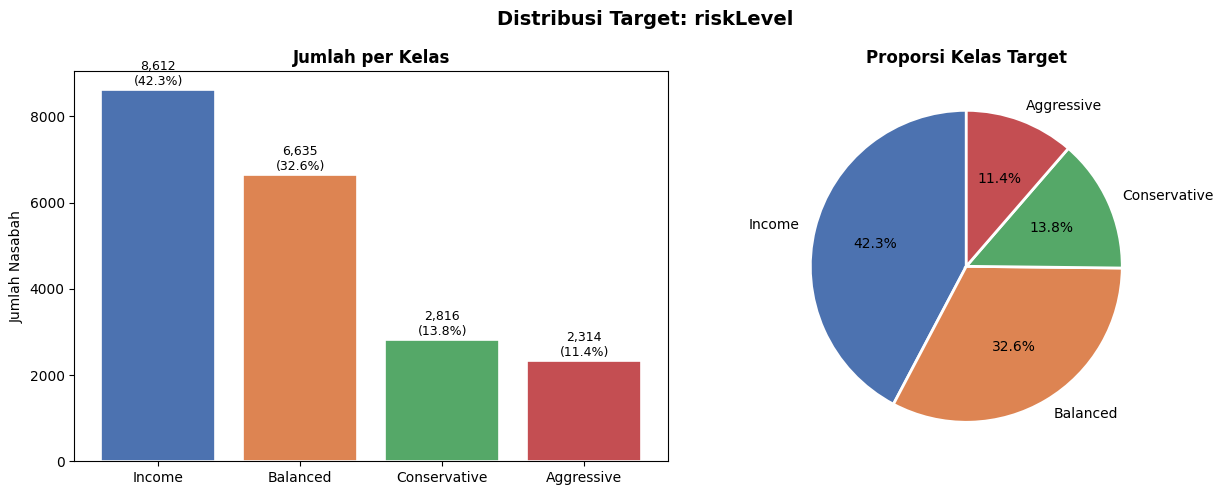

In [56]:
# ============================================================
# Visualisasi Distribusi Target
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribusi Target: riskLevel', fontsize=14, fontweight='bold')

target_counts = df['riskLevel'].value_counts()
target_pct = df['riskLevel'].value_counts(normalize=True) * 100
warna = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# Visualisasi Bar chart
bars = axes[0].bar(target_counts.index, target_counts.values, color=warna, edgecolor='white', linewidth=1.2)
axes[0].set_title('Jumlah per Kelas', fontweight='bold')
axes[0].set_ylabel('Jumlah Nasabah')

for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

# Visualisasi Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index, colors=warna, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas Target', fontweight='bold')

plt.tight_layout()
plt.show()

💡 Visualisasi mengonfirmasi temuan sebelumnya ditahap loading data dimana kelas Income mendominasi dengan 42,3% dari total nasabah, diikuti Balanced (32,6%), Conservative (13,8%), dan Aggressive sebagai kelas paling minoritas (11,4%). Pola ini 
cukup masuk akal secara bisnis, mengingat profil investor yang mencari pendapatan stabil (Income) dan seimbang (Balanced) umumnya lebih banyak ditemui dibanding investor yang benar benar konservatif maupun yang berani mengambil risiko tinggi (Aggressive), yang biasanya merupakan kelompok yang lebih spesifik dan jumlahnya lebih sedikit.

#### 4.2 Pengecekan Outlier (Metode IQR)

In [57]:
# ============================================================
# Deteksi Outlier dengan Metode IQR
# Dilakukan pada seluruh feature numerik
# ============================================================

print("=" * 50)
print("\t Deteksi Outlier dengan IQR")
print("=" * 50)
print(f"{'Kolom':<30} {'IQR':>12} {'Lower':>14} {'Upper':>14}"
      f"{'Outlier':>12} {'Persen':>8}")
print("-" * 95)

ringkasan_outlier = {}

for kolom in kolom_numerik:
    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((df[kolom] < lower) | (df[kolom] > upper)).sum()
    persen = n_outlier / len(df) * 100

    ringkasan_outlier[kolom] = {
        'IQR': IQR, 'Lower Bound': lower, 'Upper Bound': upper,
        'Jumlah Outlier': n_outlier, 'Persentase': persen
    }

    print(f"  {kolom:<28} {IQR:>12.2f} {lower:>14.2f}" 
          f"  {upper:>14.2f} {n_outlier:>10,} {persen:>7.2f}%")

	 Deteksi Outlier dengan IQR
Kolom                                   IQR          Lower          Upper     Outlier   Persen
-----------------------------------------------------------------------------------------------
  total_transactions                   7.00          -8.50           19.50      2,884   14.15%
  buy_count                            4.00          -5.00           11.00      2,996   14.70%
  sell_count                           3.00          -3.50            8.50      2,581   12.67%
  num_unique_assets                    3.00          -3.50            8.50      1,879    9.22%
  num_unique_asset_categories          0.00           1.00            1.00      2,306   11.32%
  total_buy_value                  19067.94      -27501.90        48769.84      3,061   15.02%
  total_sell_value                 11385.49      -17075.85        28466.12      3,188   15.65%
  total_transaction_value          30267.82      -43501.74        77569.56      3,092   15.17%
  avg_transaction_va

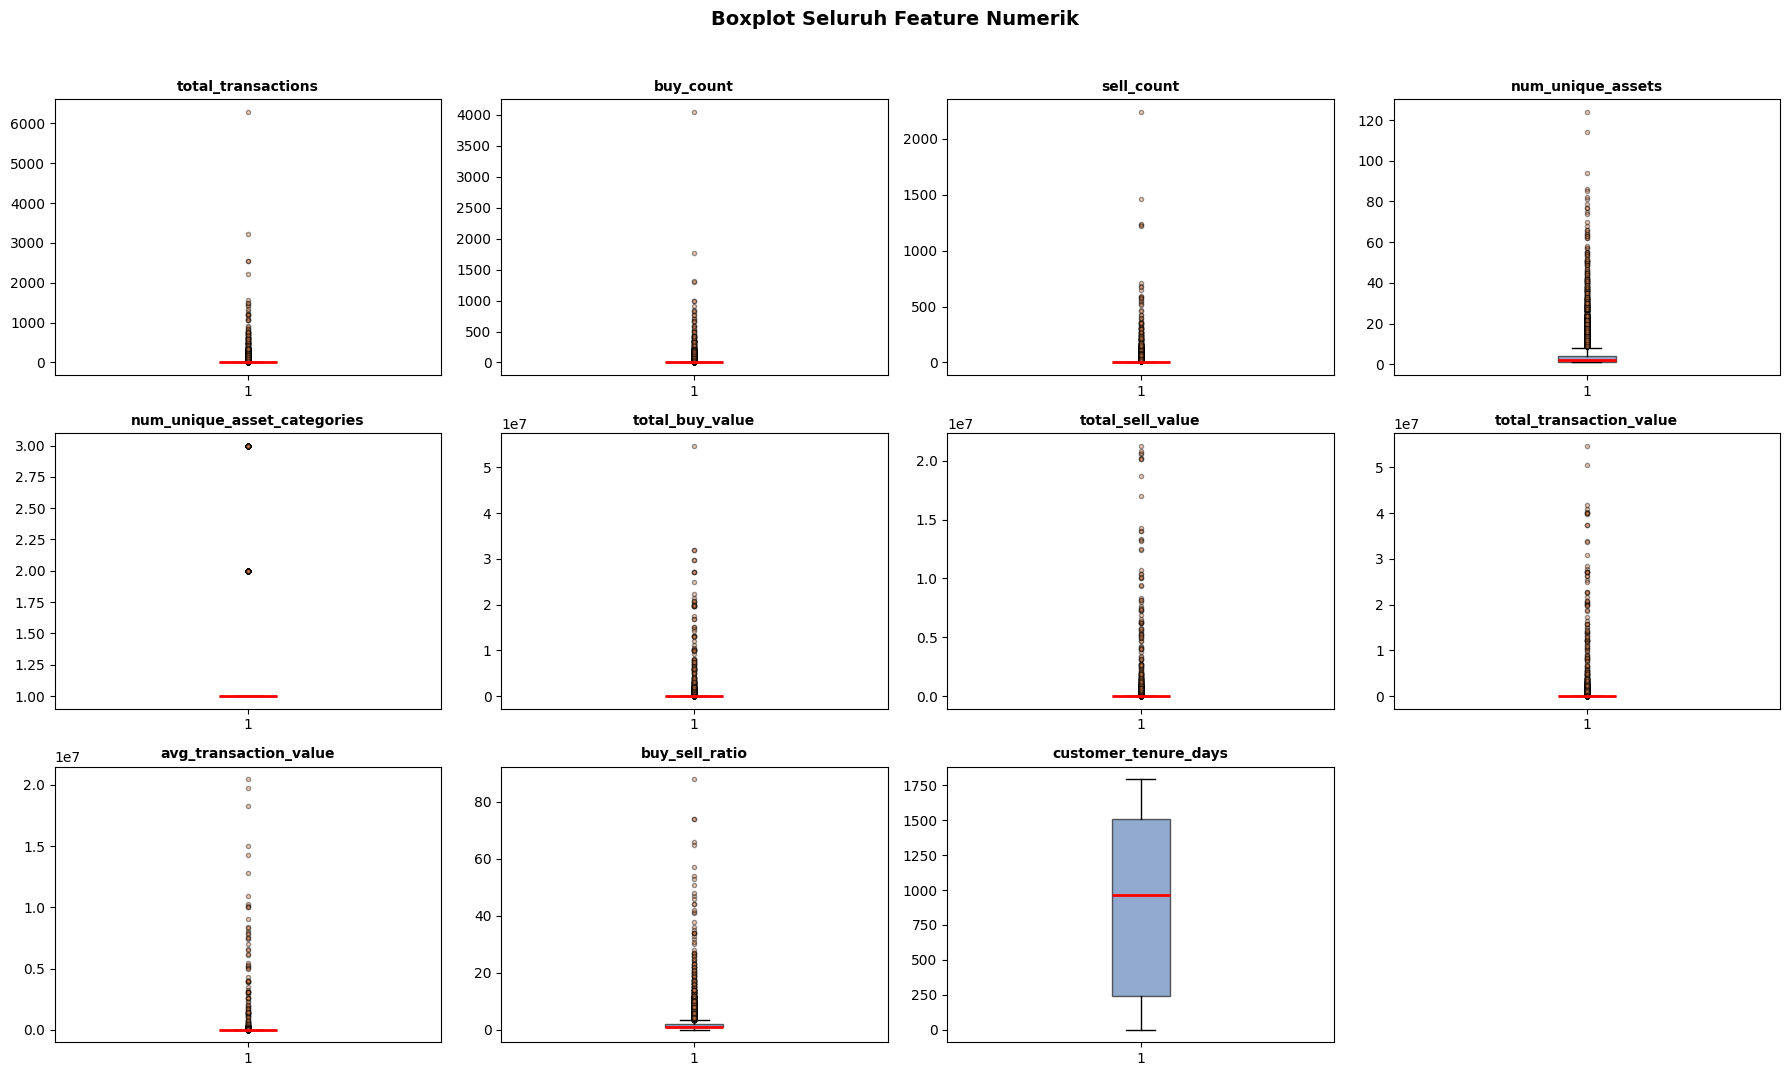

In [58]:
# ============================================================
# Visualisasi Boxplot pada Feature Numerik
# ============================================================

# Hitung jumlah kolom Numerik dan tentukan jumlah kolom subplot
n_kolom = len(kolom_numerik)
n_cols_grid = 4
n_rows_grid = -(-n_kolom // n_cols_grid)

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(18, n_rows_grid * 3.5))
axes = axes.flatten()

for i, kolom in enumerate(kolom_numerik):
    axes[i].boxplot(df[kolom], vert=True, patch_artist=True,boxprops=dict(facecolor='#4C72B0', alpha=0.6), medianprops=dict(color='red', linewidth=2), flierprops=dict(marker='o', markerfacecolor='#DD8452', markersize=3, alpha=0.4))
    axes[i].set_title(kolom, fontsize=10, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot Seluruh Feature Numerik', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

🔍 Hasil deteksi outlier dengan metode IQR menunjukkan bahwa hampir seluruh feature numerik (kecuali customer_tenure_days) memiliki persentase outlier yang cukup tinggi, berkisar antara 9.22% hingga 15,65%. Beberapa hal yang dapat diamati:
1. **Feature terkait nilai transaksi** (total_buy_value, total_sell_value, total_transaction_value) memiliki persentase outlier tertinggi, masing masing di atas 15%. Hal ini wajar mengingat dataset mencakup nasabah lintas segmen (Mass hingga Premium dan Professional), sehingga skala nilai transaksi antar nasabah secara alami sangat bervariasi.
2. **customer_tenure_days tidak memiliki outlier sama sekali (0%)**, menunjukkan bahwa lama menjadi nasabah aktif terdistribusi dalam rentang yang relatif wajar, tanpa nilai ekstrem yang menyimpang jauh dari mayoritas data. Hal ini terlihat jelas pada boxplot, di mana customer_tenure_days adalah satu satunya feature dengan bentuk kotak (IQR) yang proporsional dan tanpa titik outlier.
3. **num_unique_asset_categories menunjukkan pola yang menarik**, di mana metode IQR mendeteksi 11.32% outlier, padahal nilai pada kolom ini hanya berkisar 1 hingga 3 (sesuai jumlah kategori aset yang memang terbatas: Stock, Bond, MTF). Hal ini terjadi karena IQR pada kolom ini sangat kecil (Q1 dan Q3 keduanya bernilai 1, sehingga IQR = 0), membuat metode IQR menjadi terlalu sensitif pada feature dengan variasi nilai yang sempit.
4. Pada boxplot, seluruh feature (total_buy_value, total_sell_value, total_transaction_value, avg_transaction_value) dan feature transaksi (total_transactions, buy_count, sell_count, buy_sell_ratio) menunjukkan bentuk kotak yang sangat rapat di dekat nilai 0, dengan ekor outlier yang memanjang sangat jauh ke atas. Pola ini mengindikasikan distribusi yang sangat right skewed, yang akan dikonfirmasi lebih lanjut pada hasil pengecekan skewness dan kurtosis.

#### 4.3 Pengecekan Skewness dan Kurtosis

In [59]:
# ============================================================
# Pengcheckan Skewness dan Kurtosis
# Skewness mengukur kemiringan distribusi, kurtosis mengukur keruncingan distribusi dibanding distribusi normal
# ============================================================

skew_kurt_df = pd.DataFrame({
    'Skewness': df[kolom_numerik].skew(),
    'Kurtosis': df[kolom_numerik].kurt()
})

print("=" * 60)
print("\t Skewness dan Kurtosis per Kolom")
print("=" * 60)
print(f"{'Kolom':<30} {'Skewness':>14} {'Kurtosis':>14}")
print("-" * 60)
for kolom in kolom_numerik:
    print(f"  {kolom:<28} {skew_kurt_df.loc[kolom, 'Skewness']:>14.4f} "
          f"{skew_kurt_df.loc[kolom, 'Kurtosis']:>14.4f}")

	 Skewness dan Kurtosis per Kolom
Kolom                                Skewness       Kurtosis
------------------------------------------------------------
  total_transactions                  32.4532      1891.6800
  buy_count                           37.1980      2543.9867
  sell_count                          26.8654      1185.6516
  num_unique_assets                    5.8152        56.7705
  num_unique_asset_categories          2.9889         8.7574
  total_buy_value                     24.3041       789.9318
  total_sell_value                    23.0438       633.6806
  total_transaction_value             20.1355       486.4904
  avg_transaction_value               29.9937      1093.8778
  buy_sell_ratio                      11.7909       240.2061
  customer_tenure_days                -0.1153        -1.5037


In [60]:
# ============================================================
# Summary Outlier, Skewness, dan Kurtosis
# ============================================================

ringkasan_gabungan = pd.DataFrame({
    'Jumlah Outlier': [ringkasan_outlier[k]['Jumlah Outlier'] for k in kolom_numerik],
    'Persentase Outlier (%)': [round(ringkasan_outlier[k]['Persentase'], 2) for k in kolom_numerik],
    'Skewness': skew_kurt_df['Skewness'].round(4),
    'Kurtosis': skew_kurt_df['Kurtosis'].round(4)
}, index=kolom_numerik)

print("=" * 60)
print("\t Summary Outlier, Skewness, dan Kurtosis")
print("=" * 60)
display(ringkasan_gabungan.sort_values('Persentase Outlier (%)', ascending=False))

	 Summary Outlier, Skewness, dan Kurtosis


,Jumlah Outlier,Persentase Outlier (%),Skewness,Kurtosis
total_sell_value,3188,15.65,23.0438,633.6806
total_transaction_value,3092,15.17,20.1355,486.4904
total_buy_value,3061,15.02,24.3041,789.9318
buy_count,2996,14.70,37.1980,2543.9867
total_transactions,2884,14.15,32.4532,1891.6800
sell_count,2581,12.67,26.8654,1185.6516
avg_transaction_value,2314,11.36,29.9937,1093.8778
num_unique_asset_categories,2306,11.32,2.9889,8.7574
buy_sell_ratio,1927,9.46,11.7909,240.2061
num_unique_assets,1879,9.22,5.8152,56.7705


🔎 Hasil skewness dan kurtosis menunjukkan tingkat penyimpangan yang sangat ekstrem dari distribusi normal pada hampir seluruh feature, berikut adalah detailnya:

1. **buy_count memiliki skewness (37.1980) dan kurtosis (2543.9867) 
   paling ekstrem** di antara seluruh feature, diikuti total_transactions 
   (skewness 32.4532, kurtosis 1891.6800). Nilai kurtosis di atas 1000 ini 
   menunjukkan distribusi yang sangat leptokurtic, yaitu mayoritas data 
   terpusat sangat rapat pada nilai rendah, namun terdapat segelintir 
   nasabah dengan jumlah transaksi yang jauh melampaui mayoritas (sesuai 
   temuan boxplot sebelumnya, ada nasabah dengan total_transactions hingga 
   lebih dari 6.000, sementara median hanya 3).

2. **Seluruh feature terkait nilai transaksi** (total_buy_value, 
   total_sell_value, total_transaction_value, avg_transaction_value) 
   konsisten menunjukkan skewness di atas 20 dan kurtosis di atas 480, 
   mengonfirmasi adanya segelintir nasabah dengan nilai transaksi yang jauh 
   lebih besar dibanding mayoritas nasabah lain, sejalan dengan karakteristik 
   dataset yang mencakup nasabah lintas segmen (Mass hingga Premium).

3. **customer_tenure_days adalah satu satunya feature dengan skewness dan 
   kurtosis mendekati nol** (skewness -0,1153, kurtosis -1,5037). Kurtosis 
   negatif ini menunjukkan distribusi yang lebih landai (platykurtic) 
   dibanding distribusi normal, namun tetap relatif simetris. Hal ini 
   konsisten dengan temuan sebelumnya bahwa feature ini tidak memiliki 
   outlier sama sekali.

4. Menariknya, **num_unique_asset_categories memiliki skewness dan 
   kurtosis yang jauh lebih rendah** (2.9889 dan 8.7574) dibanding feature 
   lain, meskipun sebelumnya terdeteksi memiliki 11.32% outlier menurut 
   metode IQR. Hal ini memperkuat kesimpulan sebelumnya bahwa outlier yang 
   terdeteksi pada feature ini lebih disebabkan oleh sensitivitas metode 
   IQR terhadap feature dengan rentang nilai yang sempit (1 hingga 3), bukan 
   karena distribusinya benar benar ekstrem.

#### 4.4 Korelasi Antar Feature Numerik

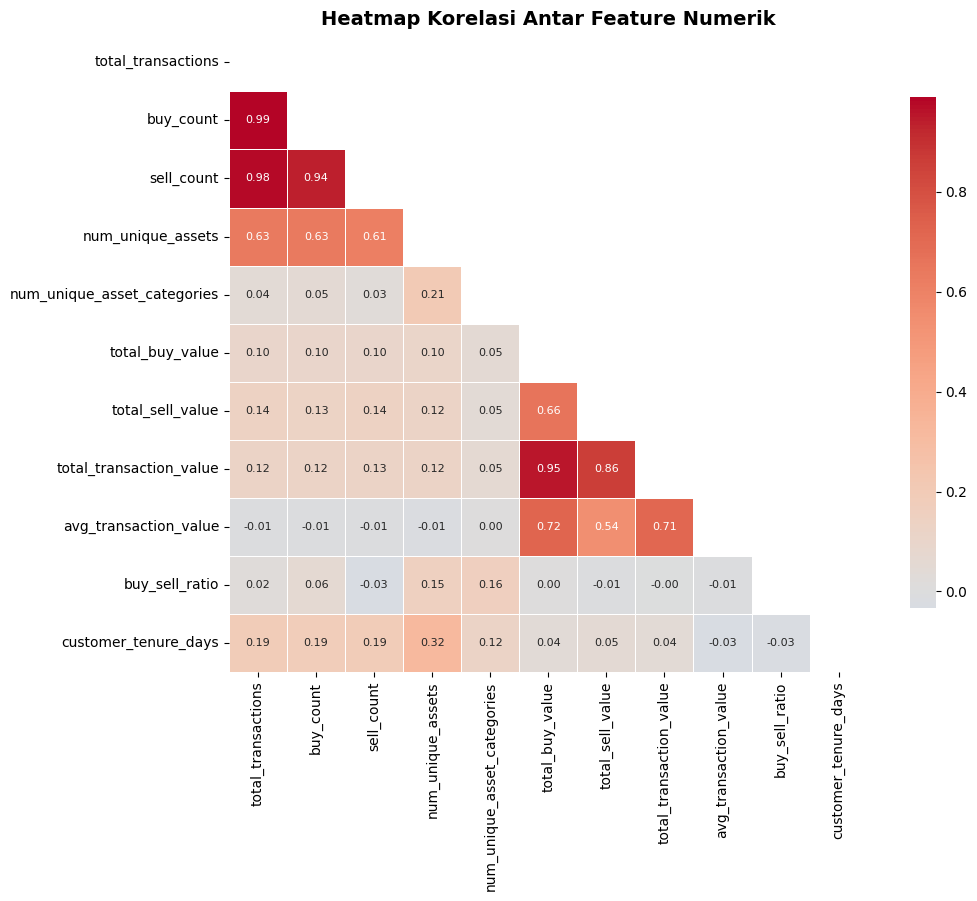

In [61]:
# ============================================================
# Heatmap Korelasi antar Feature Numerik
# ============================================================

matriks_korelasi = df[kolom_numerik].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(matriks_korelasi, dtype=bool))
sns.heatmap(matriks_korelasi, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax, annot_kws={'size': 8})
ax.set_title('Heatmap Korelasi Antar Feature Numerik', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [62]:
# ============================================================
# Daftar Pasangan Feature dengan Korelasi Tinggi
# Threshold 0.7 digunakan sebagai acuan redundansi tinggi
# ============================================================

threshold_korelasi = 0.7
pasangan_korelasi_tinggi = []

for i in range(len(matriks_korelasi.columns)):
    for j in range(i + 1, len(matriks_korelasi.columns)):
        nilai_korelasi = matriks_korelasi.iloc[i, j]
        if abs(nilai_korelasi) >= threshold_korelasi:
            pasangan_korelasi_tinggi.append((
                matriks_korelasi.columns[i],
                matriks_korelasi.columns[j],
                round(nilai_korelasi, 4)
            ))

print("=" * 70)
print(f"Pasangan Feature dengan Korelasi Tinggi >= {threshold_korelasi}")
print("=" * 70)

if pasangan_korelasi_tinggi:
    for f1, f2, korelasi in sorted(pasangan_korelasi_tinggi, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {f1:<30} - {f2:<30} : {korelasi:>7.4f}")
else:
    print(f"Tidak ditemukan pasangan feature dengan korelasi mutlak >= {threshold_korelasi}")

Pasangan Feature dengan Korelasi Tinggi >= 0.7
  total_transactions             - buy_count                      :  0.9892
  total_transactions             - sell_count                     :  0.9797
  total_buy_value                - total_transaction_value        :  0.9519
  buy_count                      - sell_count                     :  0.9397
  total_sell_value               - total_transaction_value        :  0.8605
  total_buy_value                - avg_transaction_value          :  0.7180
  total_transaction_value        - avg_transaction_value          :  0.7114


📌 Heatmap korelasi menunjukkan adanya beberapa kelompok feature dengan 
redundansi informasi yang sangat tinggi, terutama pada pasangan dengan 
korelasi di atas 0.7, yaitu:

1. **Kelompok feature jumlah transaksi** (total_transactions, buy_count, 
   sell_count) saling berkorelasi sangat tinggi (0.94 hingga 0.99). Hal 
   ini sangat masuk akal secara matematis, dimana total_transactions 
   merupakan hasil penjumlahan langsung dari buy_count dan sell_count, 
   sehingga ketiganya pada dasarnya mengukur informasi yang hampir sama.

2. **Kelompok feature nilai transaksi** (total_buy_value, total_sell_value, 
   total_transaction_value, avg_transaction_value) juga saling 
   berkorelasi tinggi (0.71 hingga 0.95). Pola ini juga sejalan dengan 
   definisi data, dimana total_transaction_value merupakan hasil 
   penjumlahan total_buy_value dan total_sell_value, sedangkan 
   avg_transaction_value diperoleh dari pembagian total nilai transaksi 
   terhadap jumlah transaksi.

3. **num_unique_assets berkorelasi sedang (0.61 hingga 0.63)** terhadap 
   ketiga feature jumlah transaksi, menunjukkan nasabah yang lebih sering 
   bertransaksi cenderung memiliki jumlah aset unik yang lebih banyak pula, 
   meski tidak sekuat korelasi pada kelompok pertama.

4. **buy_sell_ratio dan customer_tenure_days relatif independen** 
   terhadap feature lainnya, dengan korelasi yang sangat rendah (mayoritas 
   di bawah 0,2) terhadap seluruh feature numerik lain, menunjukkan kedua 
   feature ini membawa informasi yang relatif unik dan tidak banyak 
   tumpang tindih dengan feature lainnya.

⚠️ Tingginya korelasi pada beberapa kelompok feature ini terjadi karena adanya 
**hubungan matematis langsung** antar feature (feature satu adalah hasil 
turunan/agregasi dari feature lainnya), bukan murni korelasi alami dari 
perilaku data. Sehingga bisa menjadi pertimbangan saat melakukan feature selection di tahap feature engineering.

#### 4.5 Korelasi Feature Numerik dengan Target

Mengingat target (riskLevel) bersifat kategorikal dengan 4 kelas (bukan biner), digunakan **ANOVA F-test** untuk menguji hubungan setiap feature numerik dengan target.

In [63]:
# ============================================================
# ANOVA F-TEST: Feature Numerik vs Target (riskLevel)
# Menguji apakah rata rata suatu feature berbeda signifikan antar kelas riskLevel.
# ============================================================

print("=" * 70)
print("\t ANOVA F-TEST: Feature Numerik vs Target(riskLevel)")
print("=" * 70)
print(f"{'Feature':<30} {'F-Statistic':>15} {'P-Value':>15} {'Signifikan':>12}")
print("-" * 75)

hasil_anova = {}
for kolom in kolom_numerik:
    grup = [df[df['riskLevel'] == kelas][kolom] for kelas in df['riskLevel'].unique()]
    f_stat, p_val = f_oneway(*grup)
    signifikan = "Ya" if p_val < 0.05 else "Tidak"
    hasil_anova[kolom] = {'F-Statistic': f_stat, 'P-Value': p_val}
    print(f"  {kolom:<28} {f_stat:>15.4f} {p_val:>15.4e} {signifikan:>12}")

	 ANOVA F-TEST: Feature Numerik vs Target(riskLevel)
Feature                            F-Statistic         P-Value   Signifikan
---------------------------------------------------------------------------
  total_transactions                   55.2035      1.5698e-35           Ya
  buy_count                            64.1535      2.8070e-41           Ya
  sell_count                           40.7797      2.8959e-26           Ya
  num_unique_assets                   263.7016     6.4346e-168           Ya
  num_unique_asset_categories         181.2598     5.4063e-116           Ya
  total_buy_value                      43.0949      9.4310e-28           Ya
  total_sell_value                     22.6921      1.1642e-14           Ya
  total_transaction_value              40.7356      3.0912e-26           Ya
  avg_transaction_value                18.0285      1.1138e-11           Ya
  buy_sell_ratio                      185.0115     2.2771e-118           Ya
  customer_tenure_days             

📝 Seluruh feature numerik menunjukkan hubungan yang signifikan secara 
statistik terhadap riskLevel (p-value seluruhnya jauh di bawah 0.05). 
Namun, kekuatan hubungan yang ditunjukkan oleh F-statistic sangat bervariasi:

1. **num_unique_assets memiliki F-statistic tertinggi (263.70)**, diikuti 
   buy_sell_ratio (185.01) dan num_unique_asset_categories (181.26). 
   Ketiga feature ini mengindikasikan bahwa diversifikasi portofolio 
   (jumlah aset unik dan jumlah kategori aset yang dimiliki) serta 
   kecenderungan membeli dibanding menjual, merupakan sinyal yang relatif 
   kuat dalam membedakan profil risiko nasabah dibanding feature lainnya.

2. **customer_tenure_days memiliki F-statistic paling rendah (5.34)** 
   di antara seluruh feature numerik, meskipun tetap signifikan secara 
   statistik. Hal ini menunjukkan bahwa lama menjadi nasabah aktif memiliki 
   hubungan yang jauh lebih lemah terhadap profil risiko dibanding feature 
   perilaku transaksi lainnya.

3. Feature terkait nilai transaksi (total_buy_value, total_sell_value, 
   total_transaction_value, avg_transaction_value) menunjukkan 
   F-statistic pada rentang menengah (18 hingga 43), lebih rendah dibanding 
   feature terkait diversifikasi dan jumlah transaksi.

#### 4.6 Korelasi Feature Kategorikal dengan Target

Untuk menguji hubungan antara feature kategorikal dengan target kategorikal, digunakan **Chi-Square Test of Independence**, yang sesuai untuk menguji apakah dua variabel kategorikal saling bergantung atau tidak.

In [64]:
# ============================================================
# CHI-SQUARE TEST: Feature Kategorikal vs Target (riskLevel)
# ============================================================

print("=" * 70)
print("\t CHI-SQUARE TEST: Feature Kategorikal vs Target(riskLevel)")
print("=" * 70)
print(f"{'Feature':<30} {'Chi2-Statistic':>16} {'P-Value':>15} {'Signifikan':>12}")
print("-" * 76)

hasil_chi2 = {}
for kolom in kolom_kategorikal_feature:
    tabel_kontingensi = pd.crosstab(df[kolom], df['riskLevel'])
    chi2, p_val, dof, expected = chi2_contingency(tabel_kontingensi)
    signifikan = "Ya" if p_val < 0.05 else "Tidak"
    hasil_chi2[kolom] = {'Chi2-Statistic': chi2, 'P-Value': p_val}
    print(f"  {kolom:<28} {chi2:>16.4f} {p_val:>15.4e} {signifikan:>12}")

	 CHI-SQUARE TEST: Feature Kategorikal vs Target(riskLevel)
Feature                          Chi2-Statistic         P-Value   Signifikan
----------------------------------------------------------------------------
  customerType                        1988.8489      0.0000e+00           Ya
  investmentCapacity                  2297.3756      0.0000e+00           Ya
  dominant_channel                    1182.2319     3.3527e-252           Ya
  dominant_asset_category              892.9480     1.2569e-189           Ya


📝 Seluruh feature kategorikal juga menunjukkan hubungan yang signifikan 
terhadap riskLevel (p-value dibawah 0.05 untuk seluruh feature):

1. **investmentCapacity memiliki Chi2-statistic tertinggi (2297.38)**, 
   diikuti customerType (1988.85). Kedua feature ini berkaitan langsung 
   dengan kemampuan finansial nasabah, sehingga wajar memiliki asosiasi 
   yang sangat kuat terhadap profil risiko investasi.

2. **dominant_channel dan dominant_asset_category juga menunjukkan Chi2-statistic yang besar** (1182.23 dan 892.95), menunjukkan bahwa kanal transaksi yang biasa digunakan nasabah dan jenis aset yang dominan dimiliki juga memiliki asosiasi yang kuat terhadap profil risiko.


📌 Secara keseluruhan, baik feature numerik maupun kategorikal pada dataset ini menunjukkan hubungan yang signifikan terhadap target, mengindikasikan bahwa seluruh feature yang tersedia berpotensi memiliki kontribusi terhadap pembentukan model klasifikasi profil risiko nasabah.

---

### **5. Feature Engineering**

Berdasarkan hasil EDA pada tahap sebelumnya, berikut adalah rangkaian proses 
Feature Engineering yang akan dilakukan sebelum melatih model, mencakup feature selection, 
penanganan cardinality, pembagian data train-test, penanganan outlier, 
encoding, dan scaling, agar data yang digunakan dapat menghasilkan performa 
model yang maksimal.

#### 5.1 Feature Selection

Berdasarkan hasil heatmap korelasi dan ANOVA F-test di tahap EDA, ditemukan 
dua kelompok feature dengan redundansi tinggi yang dapat dijelaskan secara 
matematis, sehingga dilakukan Feature Selection manual dengan memilih satu representatif terbaik dari setiap kelompok, berdasarkan F-statistic tertinggi pada kelompok tersebut.

**✦ Kelompok 1 - Jumlah Transaksi**

| Feature | Korelasi dalam kelompok | F-Statistic |
|---|---|---|
| total_transactions | 0.98-0.99 | 55.20 |
| buy_count | 0.94-0.99 | 64.15 |
| sell_count | 0.94-0.98 | 40.78 |

Dipilih **buy_count** sebagai representatif, karena memiliki F-statistic 
tertinggi (64.15) di antara ketiganya, menunjukkan kemampuan membedakan 
profil risiko yang paling kuat pada kelompok ini. total_transactions dan 
sell_count di-drop karena informasinya sudah terwakili (secara matematis, 
total_transactions = buy_count + sell_count).

**✦ Kelompok 2 - Nilai Transaksi**

| Feature | Korelasi dalam kelompok | F-Statistic |
|---|---|---|
| total_buy_value | 0.72-0.95 | 43.09 |
| total_sell_value | 0.71-0.86 | 22.69 |
| total_transaction_value | 0.71-0.95 | 40.74 |
| avg_transaction_value | 0.71-0.72 | 18.03 |

Dipilih **total_buy_value** sebagai representatif, karena memiliki 
F-statistic tertinggi (43.09) di antara keempatnya. Ketiga feature lainnya 
di-drop, mengingat total_transaction_value adalah hasil penjumlahan 
total_buy_value dan total_sell_value, sementara avg_transaction_value 
adalah hasil pembagian total nilai transaksi terhadap jumlah transaksi, 
sehingga seluruhnya merepresentasikan informasi yang sama secara matematis.

**✦ Feature yang Dipertahankan Tanpa Perubahan**

Feature berikut dipertahankan karena tidak termasuk dalam kelompok redundan 
manapun (korelasi terhadap feature lain di bawah 0.7) dan menunjukkan 
hubungan signifikan terhadap target pada ANOVA F-test:

- num_unique_assets (F-statistic 263.70, tertinggi secara keseluruhan)
- num_unique_asset_categories (F-statistic 181.26)
- buy_sell_ratio (F-statistic 185.01)
- customer_tenure_days (F-statistic 5.34, meski terlemah, tetap signifikan 
  dan membawa informasi yang independen dari feature lain)

**Ringkasan Feature Numerik Final**

| Feature | Keputusan |
|---|---|
| buy_count | Keep (representatif kelompok jumlah transaksi) |
| total_transactions | Drop (redundan dengan buy_count + sell_count) |
| sell_count | Drop (redundan, informasi sudah terwakili buy_count) |
| total_buy_value | Keep (representatif kelompok nilai transaksi) |
| total_sell_value | Drop (redundan dengan total_buy_value) |
| total_transaction_value | Drop (hasil penjumlahan buy + sell value) |
| avg_transaction_value | Drop (hasil pembagian total value / jumlah transaksi) |
| num_unique_assets | Keep |
| num_unique_asset_categories | Keep |
| buy_sell_ratio | Keep |
| customer_tenure_days | Keep |

Seluruh feature kategorikal (customerType, investmentCapacity, 
dominant_channel, dominant_asset_category) dipertahankan seluruhnya, 
mengingat keempatnya menunjukkan asosiasi yang sangat signifikan terhadap 
target pada Chi-Square Test, dan tidak ada indikasi redundansi antar 
feature kategorikal tersebut.


In [65]:
# ============================================================
# Feature Selection - Drop Feature Redundan
# Total Feature Numerik setelah Feature Selection
# ============================================================
feature_didrop = ['total_transactions', 'sell_count', 'total_sell_value', 'total_transaction_value',
                  'avg_transaction_value']
df = df.drop(columns=feature_didrop)
# Cetak Feature yang di drop
print(f"Feature yang di-drop : {feature_didrop}")

kolom_numerik = [k for k in kolom_numerik if k not in feature_didrop]
# Cetak sisa feature numerik setelah feature selection
print(f"\n Total feature numerik setelah Feature Selection : {kolom_numerik}")
print(f"\n Jumlah : {len(kolom_numerik)}")

Feature yang di-drop : ['total_transactions', 'sell_count', 'total_sell_value', 'total_transaction_value', 'avg_transaction_value']

 Total feature numerik setelah Feature Selection : ['buy_count', 'num_unique_assets', 'num_unique_asset_categories', 'total_buy_value', 'buy_sell_ratio', 'customer_tenure_days']

 Jumlah : 6


In [66]:
# ============================================================
# Summary Feature Selection
# ============================================================
print(f"Shape setelah Feature Selection : {df.shape}")
print(f"\nKolom yang tersisa   : {list(df.columns)}")

Shape setelah Feature Selection : (20377, 11)

Kolom yang tersisa   : ['customerType', 'investmentCapacity', 'dominant_channel', 'dominant_asset_category', 'buy_count', 'num_unique_assets', 'num_unique_asset_categories', 'total_buy_value', 'buy_sell_ratio', 'customer_tenure_days', 'riskLevel']


📝 Setelah dilakukan Feature Selection dengan men-drop lima feature yang 
redundan secara matematis (total_transactions, sell_count, total_sell_value, 
total_transaction_value, avg_transaction_value), dataset tersisa 11 kolom 
dari sebelumnya 16 kolom, dengan rincian:
- 4 feature kategorikal: customerType, investmentCapacity, dominant_channel, dominant_asset_category.
- 6 feature numerik: buy_count, num_unique_assets, num_unique_asset_categories, total_buy_value, buy_sell_ratio, customer_tenure_days.
- 1 target: riskLevel.

📍 Jumlah baris tetap 20.377, menunjukkan proses ini hanya mengurangi jumlah 
kolom tanpa kehilangan satu pun baris data. Pengurangan dimensi ini cukup 
signifikan, dari 11 feature numerik awal menjadi 6 (setelah drop), namun 
yang dipertahankan adalah feature dengan kontribusi signifikan paling 
tinggi terhadap target sesuai hasil ANOVA F-test sebelumnya, sehingga 
diharapkan tidak banyak kehilangan informasi yang relevan untuk proses 
klasifikasi profil risiko nasabah.


#### 5.2 Handling Missing Value
Berdasarkan pengcheckan missing value pada tahapan Data Loading sebelumnya, kita ketahui bahawa pada dataset ini tidak terdapat data yang missing value sehingga proses ini tidak dibutuhkan.

#### 5.3 Handling Cardinality
Pada tahap eksplorasi awal, ditemukan bahwa kolom **investmentCapacity** 
memiliki 9 nilai unik, padahal secara definisi seharusnya hanya terdiri 
dari 4 kategori inti (CAP_LT30K, CAP_30K_80K, CAP_80K_300K, CAP_GT300K). 
Kelebihan nilai unik ini disebabkan oleh adanya prefix Predicted_ pada 
sebagian data, yang menandakan bahwa nilai kapasitas investasi tersebut 
merupakan hasil estimasi otomatis oleh sistem bank, bukan hasil pengisian 
langsung melalui kuesioner oleh nasabah. Secara konsep, nilai Predicted_CAP_LT30K dan CAP_LT30K merepresentasikan kategori kapasitas investasi yang sama (di bawah 30 ribu euro), hanya berbeda 
pada sumber/metode perolehan datanya. Karena tujuan project ini adalah 
memprediksi profil risiko berdasarkan kategori kapasitas investasi itu 
sendiri (bukan menilai keandalan sumber datanya), maka prefix Predicted_ 
akan dihapus begitu pula juga dengan nilai Not_Available yang tidak membawa informasi apapun (seperti yang sudah di jelaskan pada tahapan Data Loading).

In [67]:
# ============================================================
# Handling Cardinality - investmentCapacity
# Menghapus prefix 'Predicted_' agar nilai yang merepresentasikan kategori kapasitas investasi yang sama tergabung jadi satu,
# ============================================================

print("Nilai unik sebelum Handling Cardinality:")
print(df['investmentCapacity'].unique())
print(f"Jumlah nilai unik : {df['investmentCapacity'].nunique()}")

# Hapus nilai Predicted_
df['investmentCapacity'] = df['investmentCapacity'].str.replace('Predicted_', '', regex=False)

# Hapus baris dengan Not_Available
df = df[df['investmentCapacity'] != 'Not_Available'].reset_index(drop=True)

print("\nNilai unik setelah Handling Cardinality:")
print(df['investmentCapacity'].unique())
print(f"Jumlah nilai unik : {df['investmentCapacity'].nunique()}")

Nilai unik sebelum Handling Cardinality:
['Predicted_CAP_LT30K' 'CAP_LT30K' 'CAP_80K_300K' 'CAP_30K_80K'
 'Predicted_CAP_80K_300K' 'CAP_GT300K' 'Predicted_CAP_30K_80K'
 'Predicted_CAP_GT300K' 'Not_Available']
Jumlah nilai unik : 9

Nilai unik setelah Handling Cardinality:
['CAP_LT30K' 'CAP_80K_300K' 'CAP_30K_80K' 'CAP_GT300K']
Jumlah nilai unik : 4


#### 5.4 Train-Test Split
Pembagian data menjadi train-set dan test-set dilakukan sebelum proses handling outlier, 
encoding, dan scaling, untuk mencegah data leakage. Pembagian ini akan menggunakan metode **stratified split** berdasarkan target `riskLevel`, 
mengingat distribusi target yang tidak seimbang (rasio 3.7:1 antara kelas 
terbesar dan terkecil). Stratified split memastikan proporsi keempat kelas 
tetap terjaga baik pada train-set maupun test-set, sehingga evaluasi model 
nantinya tidak bias akibat perbedaan distribusi kelas antar kedua set.

In [68]:
# ============================================================
# Memisahkan Feature (X) dan Target (y)
# ============================================================

X = df.drop(columns=['riskLevel'])
y = df['riskLevel']

print(f"Shape X (feature) : {X.shape}")
print(f"Shape y (target)  : {y.shape}")
print(f"\nKolom feature     : {list(X.columns)}")

Shape X (feature) : (20374, 10)
Shape y (target)  : (20374,)

Kolom feature     : ['customerType', 'investmentCapacity', 'dominant_channel', 'dominant_asset_category', 'buy_count', 'num_unique_assets', 'num_unique_asset_categories', 'total_buy_value', 'buy_sell_ratio', 'customer_tenure_days']


In [69]:
# ============================================================
# TRAIN-TEST Split dengan Stratifikasi
# stratify=y memastikan proporsi setiap kelas riskLevel tetap terjaga pada train-set maupun test-set
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=88,
    stratify=y
)

print("=" * 40)
print("\t Hasil TRAIN-TEST Split")
print("=" * 40)
print(f"Total data   : {len(X):,}")
print(f"Train set    : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test set     : {len(X_test):,} ({len(X_test)/len(X)*100:.0f}%)")
# Cetak nilai distribusi dari Target
print(f"\nDistribusi target - Train:")
print(y_train.value_counts())
print(f"\nDistribusi target - Test:")
print(y_test.value_counts())

	 Hasil TRAIN-TEST Split
Total data   : 20,374
Train set    : 16,299 (80%)
Test set     : 4,075 (20%)

Distribusi target - Train:
riskLevel
Income          6888
Balanced        5308
Conservative    2252
Aggressive      1851
Name: count, dtype: int64

Distribusi target - Test:
riskLevel
Income          1722
Balanced        1327
Conservative     563
Aggressive       463
Name: count, dtype: int64


📌 Proses Stratified split berhasil dilakukan dengan proporsi keempat kelas konsisten terjaga di train dan test set (rasio masing-masing kelas hampir identik antara kedua set).

#### 5.5 Handling Outlier

Berdasarkan hasil EDA sebelumnya, hampir seluruh feature numerik 
menunjukkan persentase outlier yang signifikan (9% hingga lebih dari 15%) 
disertai skewness dan kurtosis yang sangat tinggi. Mengingat project ini 
menggunakan lima algoritma dengan tingkat sensitivitas yang berbeda 
terhadap outlier, terutama KNN dan SVM yang sangat sensitif terhadap nilai 
ekstrem dan skala data, maka dipilih pendekatan **IQR Capping** (winsorizing), 
yaitu memotong nilai ekstrem ke batas atas/bawah IQR tanpa menghapus baris 
data.

Pendekatan ini dipilih dibanding menghapus baris outlier, karena:
1. Persentase outlier yang signifikan pada banyak feature berisiko 
   menghapus ribuan baris sekaligus jika dilakukan penghapusan, mengingat 
   outlier antar kolom dapat saling tumpang tindih.
2. Nilai ekstrem pada data ini kemungkinan besar merepresentasikan 
   perilaku nyata nasabah dengan aktivitas investasi yang jauh lebih 
   intensif (nasabah Premium/Professional), bukan kesalahan input data.
3. Capping tetap mempertahankan urutan relatif nasabah (nasabah dengan 
   nilai ekstrem tetap tercatat sebagai nilai tertinggi setelah capping), 
   namun mengurangi pengaruh nilai tersebut secara berlebihan terhadap 
   model yang sensitif terhadap skala seperti KNN dan SVM.

📌 Implementasi dilakukan dengan membuat **custom transformer** agar dapat 
diintegrasikan langsung ke dalam Pipeline. Batas IQR (Q1, Q3) dihitung 
**hanya dari data training** saat proses fit, kemudian batas tersebut 
digunakan untuk melakukan capping baik pada data training maupun data test, 
untuk mencegah data leakage.

In [70]:
# ============================================================
# Custom Transformer - IQR CAPPING
# Transformer ini menghitung batas IQR (Q1, Q3) hanya dari data training saat fit(), untuk memotong nilai ekstrem baik pada data training maupun data baru saat transform()
# ============================================================

# Membuat class IQR Capping
class IQRCapper(BaseEstimator, TransformerMixin):
    """
    Transformer untuk melakukan capping pada nilai outlier
    menggunakan metode IQR (Interquartile Range).

    Nilai di bawah batas bawah akan diganti dengan batas bawah,
    dan nilai di atas batas atas akan diganti dengan batas atas.
    """

    def __init__(self, factor=1.5):
        # factor menentukan seberapa jauh batas capping dari Q1/Q3
        # nilai default 1.5 mengikuti konvensi umum metode IQR
        self.factor = factor

    def fit(self, X, y=None):
        # Konversi ke DataFrame agar perhitungan per kolom lebih mudah
        X = pd.DataFrame(X)

        # Hitung Q1, Q3, dan batas bawah/atas HANYA dari data training
        self.Q1_ = X.quantile(0.25)
        self.Q3_ = X.quantile(0.75)
        self.IQR_ = self.Q3_ - self.Q1_
        self.lower_bound_ = self.Q1_ - self.factor * self.IQR_
        self.upper_bound_ = self.Q3_ + self.factor * self.IQR_
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        # Lakukan capping menggunakan batas yang sudah dihitung saat fit
        for kolom in X.columns:
            X[kolom] = X[kolom].clip(lower=self.lower_bound_[kolom], upper=self.upper_bound_[kolom])
        return X.values

# Cetak informasi Class berhasil dibuat
print("Custom transformer IQRCapper berhasil didefinisikan")

Custom transformer IQRCapper berhasil didefinisikan


In [71]:
# ============================================================
# Uji Custom Transformer Pada Feature Numerik
# Menguji transformer pada X_train untuk memastikan berfungsi dengan benar sebelum dimasukkan ke Pipeline
# ============================================================

# Panggil class yang sudah dibuat
capper_test = IQRCapper()
X_train_numerik_capped = capper_test.fit_transform(X_train[kolom_numerik])
X_train_numerik_capped = pd.DataFrame(X_train_numerik_capped, columns=kolom_numerik)

print("Statistik sebelum capping (X_train):")
display(X_train[kolom_numerik].describe().loc[['min', 'max']])

print("\nStatistik setelah capping (X_train):")
display(X_train_numerik_capped.describe().loc[['min', 'max']])

Statistik sebelum capping (X_train):


,buy_count,num_unique_assets,num_unique_asset_categories,total_buy_value,buy_sell_ratio,customer_tenure_days
min,1.0,1.0,1.0,7.360000e-02,0.012346,0.0
max,4047.0,124.0,3.0,5.478391e+07,88.000000,1793.0



Statistik setelah capping (X_train):


,buy_count,num_unique_assets,num_unique_asset_categories,total_buy_value,buy_sell_ratio,customer_tenure_days
min,1.0,1.0,1.0,0.073600,0.012346,0.0
max,11.0,8.5,1.0,48630.617121,3.500000,1793.0


**📋 Berdasarkan Handling Outlier dengan metode IQR Capping diatas terdapat beberapa poin yang bisa dijabarkan, yaitu:**

* Capping berhasil mengurangi pengaruh nilai ekstrem secara signifikan pada 
seluruh feature numerik kecuali customer_tenure_days (sesuai temuan EDA 
sebelumnya bahwa feature ini tidak memiliki outlier). Sebagai contoh, 
total_buy_value yang sebelumnya memiliki nilai maksimum mencapai 54.7 
juta euro, terpotong menjadi maksimal sekitar 48.630 euro. Pola serupa 
terlihat pada buy_count (4.047 menjadi 11) dan buy_sell_ratio (88 
menjadi 3.5). Nilai minimum pada seluruh feature tidak berubah, menunjukkan 
outlier pada dataset ini didominasi oleh nilai ekstrem di sisi atas (right 
skewed), sejalan dengan hasil skewness positif yang ditemukan pada tahap EDA.

#### 5.6 Column Transformer (Scaling + Encoding)
Setelah handling outlier dengan IQR Capping selanjutnya adalah Column Transformer dengan menggunakan pipeline dimana untuk feature numerik digunakan StandardScaler dan feature kategorikal menggunakan 2 metode OneHot dan Ordinal seperti yang sudah dijelaskan pada tahap Loading Data.

In [72]:
# ============================================================
# OneHot untuk feature customerType, dominant_channel, dominant_asset_category
# Ordinl untuk feature investmentCapacity
# ============================================================

# Memisahkan feature onehot dan ordinal
feature_onehot = ['customerType', 'dominant_channel', 'dominant_asset_category']
feature_ordinal = ['investmentCapacity']
urutan_capacity = [['CAP_LT30K', 'CAP_30K_80K', 'CAP_80K_300K', 'CAP_GT300K']]

# ============================================================
# Pipeline Preprocessing untuk Feature Numerik
# IQR Capping -> Scaling, dijalankan berurutan
# ============================================================

numeric_pipeline = Pipeline([
    ('capper', IQRCapper()),
    ('scaler', StandardScaler())
])

# ============================================================
# COLUMNTRANSFORMER - GABUNGKAN SEMUA PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, kolom_numerik),
    ('onehot', OneHotEncoder(handle_unknown='ignore'), feature_onehot),
    ('ordinal', OrdinalEncoder(categories=urutan_capacity), feature_ordinal)
])

print("Preprocessor berhasil didefinisikan")
print(preprocessor)

Preprocessor berhasil didefinisikan
ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('capper', IQRCapper()),
                                                 ('scaler', StandardScaler())]),
                                 ['buy_count', 'num_unique_assets',
                                  'num_unique_asset_categories',
                                  'total_buy_value', 'buy_sell_ratio',
                                  'customer_tenure_days']),
                                ('onehot',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['customerType', 'dominant_channel',
                                  'dominant_asset_category']),
                                ('ordinal',
                                 OrdinalEncoder(categories=[['CAP_LT30K',
                                                             'CAP_30K_80K',
                                                          

---

### **6. Model Definition**

Pada tahap ini didefinisikan 5 Pipeline yang masing masing menggabungkan 
preprocessing (IQR Capping, Scaling, Encoding) dengan satu algoritma 
klasifikasi. Kelima algoritma dilatih menggunakan parameter default 
(baseline) terlebih dahulu, kemudian dievaluasi menggunakan Cross Validation 
untuk menentukan algoritma terbaik sebelum dilakukan Hyperparameter Tuning.

- **Alasan penggunaan `class_weight='balanced'` pada algoritma yang mendukung:**
<br> Mengingat distribusi target tidak seimbang (rasio 3.7:1), parameter `class_weight='balanced'` digunakan pada algoritma yang mendukungnya (SVM, Decision Tree, Random Forest) agar model tetap memperhatikan kelas minoritas (Aggressive, Conservative) secara proporsional. KNN tidak memiliki parameter ini karena cara kerjanya berbasis jarak ke tetangga, sementara XGBoost menggunakan parameter berbeda (`scale_pos_weight`) yang hanya berlaku untuk klasifikasi biner, sehingga penyesuaian imbalance pada kedua algoritma ini akan dipertimbangkan lebih lanjut berdasarkan hasil **baseline Cross Validation**.

| Algoritma | Hyperparameter Default Kunci |
|---|---|
| KNN | n_neighbors=5 (default) |
| SVM | C=1.0, kernel='rbf', class_weight='balanced' |
| Decision Tree | class_weight='balanced', random_state=88 |
| Random Forest | n_estimators=100, class_weight='balanced', random_state=88 |
| XGBoost | n_estimators=100, random_state=88 |

In [73]:
# ============================================================
# Mpdel Definition 5 Pipline - Baseline Model
# Setiap Pipeline menggabungkan preprocessor yang sama dengan satu algoritma klasifikasi berbeda
# ============================================================

# --- Model KNN ---
pipeline_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

# --- Model SVM ---
pipeline_svm = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(class_weight='balanced', random_state=88, probability=True))
])

# --- Model Dicision Tree ---
pipeline_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(class_weight='balanced', random_state=88))
])

# --- Model Random Forest ---
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=88))
])

# --- Model XGBoost ---
pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(random_state=88, eval_metric='mlogloss'))
])

# Cetak informasi bahwa Model berhasil dibuat
print("Kelima Pipeline berhasil didefinisikan: KNN, SVM, Decision Tree, Random Forest, XGBoost")

Kelima Pipeline berhasil didefinisikan: KNN, SVM, Decision Tree, Random Forest, XGBoost


---

### **7. Model Training**

* Training dilakukan dengan parameter default (baseline) pada setiap Pipeline, kemudian dievaluasi menggunakan `cross_validate` untuk mendapatkan nilai mean dan std performa setiap model, sebelum ditentukan algoritma terbaik untuk Hyperparameter Tuning.

* XGBoost membutuhkan target berbentuk angka (bukan string), sehingga 
`riskLevel` perlu di-encode menjadi label numerik (0, 1, 2, 3) khusus untuk 
keperluan training XGBoost saja.

In [74]:
# ============================================================
# Encode Target 'riskLevel' untuk XGBOOST
# Encoder hanya di-fit pada y_train untuk menghindari data leakage
# ============================================================

# Encoding dengan metode LabelEncoder
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Cetak hasil proses Encoding pada Target
print("Mapping label encoding:")
for i, kelas in enumerate(label_encoder.classes_):
    print(f"  {kelas} -> {i}")

Mapping label encoding:
  Aggressive -> 0
  Balanced -> 1
  Conservative -> 2
  Income -> 3


In [75]:
# ============================================================
# Cross Validation untuk ke Lima Model Baseline
# Menggunakan 5-fold StratifiedKFold agar proporsi kelas tetap terjaga pada setiap fold, mengingat target imbalance
# ============================================================

# Membuat strategi Stratified K-Fold Cross Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=88)

# Membuat pipelines yang berisi seluruh model beserta target label yang digunakan.
pipelines = {
    'KNN': (pipeline_knn, y_train),
    'SVM': (pipeline_svm, y_train),
    'Decision Tree': (pipeline_dt, y_train),
    'Random Forest': (pipeline_rf, y_train),
    'XGBoost': (pipeline_xgb, y_train_encoded)
}

# Variabel untuk menampung hasil proses Cross Validation
hasil_cv = {}

for nama_model, (pipe, target) in pipelines.items():
    print(f"Menjalankan Cross Validation untuk {nama_model}...")
    cv_result = cross_validate(
        pipe, X_train, target,
        cv=cv_strategy,
        scoring=['accuracy', 'f1_macro'],
        n_jobs=-1
    )
    # Tambahkan hasil CV ke dalam variabel hasil_cv
    hasil_cv[nama_model] = {
        'accuracy_mean': cv_result['test_accuracy'].mean(),
        'accuracy_std': cv_result['test_accuracy'].std(),
        'f1_macro_mean': cv_result['test_f1_macro'].mean(),
        'f1_macro_std': cv_result['test_f1_macro'].std()
    }
# Cetak Informasi setelah proses CV selesai dilakukan ke seluruh model
print("\n✅ Cross Validation selesai untuk seluruh model")

Menjalankan Cross Validation untuk KNN...
Menjalankan Cross Validation untuk SVM...
Menjalankan Cross Validation untuk Decision Tree...
Menjalankan Cross Validation untuk Random Forest...
Menjalankan Cross Validation untuk XGBoost...

✅ Cross Validation selesai untuk seluruh model


In [76]:
# ============================================================
# Summary Hasil Cross Validation untuk ke 5 Model
# ============================================================

df_cv = pd.DataFrame(hasil_cv).T
df_cv = df_cv.sort_values('f1_macro_mean', ascending=False)

print("=" * 60)
print("\t Summary Hasil Cross Validation (5-FOLD)")
print("=" * 60)
display(df_cv.round(4)) 

	 Summary Hasil Cross Validation (5-FOLD)


,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std
SVM,0.3762,0.0065,0.3805,0.0071
XGBoost,0.4527,0.0051,0.3746,0.0046
KNN,0.4103,0.0043,0.3687,0.0076
Random Forest,0.4162,0.0057,0.3569,0.0057
Decision Tree,0.3724,0.0097,0.3323,0.0099


**⚙️ Proses Cross Validation sudah selesai dilakukan pada ke 5 Model dengan menggunakn 5 folod dan berikut penjabaran Hasil Cross Validation:**

1. **Tidak ada model yang menunjukkan performa tinggi secara absolut.** 
   Accuracy berkisar antara 37.24% hingga 45.27%, dan F1-Macro berkisar 
   antara 33.23% hingga 38.05%. Mengingat ini adalah klasifikasi 4 kelas, 
   baseline random guessing murni berada di sekitar 25% accuracy, sehingga 
   seluruh model masih lebih baik dari tebakan acak, namun performanya 
   secara keseluruhan masih tergolong rendah untuk standar klasifikasi yang 
   baik.

2. **XGBoost memiliki accuracy tertinggi (45.27%)**, namun F1-Macro nya 
   (37.46%) berada di posisi kedua, sedikit di bawah SVM. Ini mengindikasikan 
   XGBoost cenderung lebih baik memprediksi kelas mayoritas (Income, 
   Balanced) yang berkontribusi besar terhadap accuracy, namun kurang 
   seimbang dalam memprediksi seluruh kelas termasuk kelas minoritas 
   (Aggressive, Conservative) dibanding yang ditunjukkan oleh F1-Macro.

3. **SVM memiliki F1-Macro tertinggi (38.05%)** meski accuracy nya paling 
   rendah kedua (37.62%). Hal ini konsisten dengan penggunaan 
   `class_weight='balanced'` pada SVM, yang membuat model lebih 
   memperhatikan kelas minoritas, namun mengorbankan sedikit accuracy 
   keseluruhan karena prediksi pada kelas mayoritas menjadi kurang dominan.

4. **Decision Tree menunjukkan performa terendah** pada kedua metrik 
   (accuracy 37.24%, F1-Macro 33.23%) sekaligus std tertinggi (0.0097 dan 
   0.0099), mengindikasikan performa Decision Tree tunggal paling tidak 
   stabil antar fold dibanding model lainnya, kemungkinan karena 
   kecenderungan overfitting pada data training di setiap fold.

5. **Random Forest tidak menunjukkan peningkatan signifikan dibanding Decision Tree** pada F1-Macro (35.69% vs 33.23%), meski accuracy-nya sedikit lebih baik. Hal ini mengindikasikan *ensemble bagging* (teknik machine learning yang menggabungkan beberapa model) belum cukup untuk menangkap pola yang membedakan profil risiko secara lebih baik dibanding pendekatan boosting (XGBoost).

**✧ Pertimbangan Pemilihan Model Terbaik:**

Mengingat F1-Macro lebih merepresentasikan performa model secara seimbang 
di seluruh kelas (penting karena target imbalance), sementara Accuracy 
lebih merepresentasikan performa keseluruhan, kedua metrik ini menunjukkan 
hasil yang sedikit berbeda urutannya (SVM unggul di F1-Macro, XGBoost 
unggul di Accuracy). Mengingat tujuan project ini adalah membantu tim bank 
mendeteksi seluruh kategori profil risiko secara adil, termasuk kelas 
minoritas Aggressive dan Conservative yang justru penting dari sisi 
compliance/risk management, **F1-Macro dijadikan kriteria utama** dalam 
menentukan model terbaik.

📌 Berdasarkan kriteria tersebut, **SVM dipilih sebagai model terbaik** untuk 
dilanjutkan ke tahap Hyperparameter Tuning, dengan F1-Macro tertinggi 
(38.05%) di antara kelima model baseline.

#### 7.1 Hyperparameter Tuning

Berdasarkan hasil Cross Validation sebelumnya, **SVM** dipilih sebagai 
algoritma terbaik (F1-Macro tertinggi, 38.05%). Pada tahap ini dilakukan 
Hyperparameter Tuning menggunakan **GridSearchCV** untuk mencari kombinasi 
parameter optimal, dengan scoring `f1_macro` agar konsisten dengan kriteria 
pemilihan model terbaik sebelumnya, mengingat target bersifat multi-class 
dan tidak seimbang.

**Parameter yang di-tuning:**

| Parameter | Nilai yang Diuji | Alasan |
|---|---|---|
| `C` | [0.1, 1, 10] | Mengatur trade-off antara margin lebar dan kesalahan klasifikasi; nilai kecil menghasilkan margin lebih lebar (lebih toleran kesalahan), nilai besar lebih ketat |
| `kernel` | ['rbf', 'linear'] | Menguji apakah hubungan antar feature lebih bersifat linear atau non-linear |
| `gamma` | ['scale', 'auto'] | Mengatur seberapa jauh pengaruh satu titik data terhadap pembentukan keputusan, khusus untuk kernel non-linear (rbf) |

In [77]:
# ============================================================
# GRIDSEARCHCV UNTUK SVM
# Menggunakan scoring f1_macro, konsisten dengan kriteria
# pemilihan model terbaik pada tahap Cross Validation
# ============================================================

# Definisi Parameter yang digunaan
param_grid_svm = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['rbf', 'linear'],
    'model__gamma': ['scale', 'auto']
}

# Menggunakan GridSearchCV untuk mencari kombinasi
grid_search_svm = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=param_grid_svm,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print("Menjalankan GridSearchCV untuk SVM, ⌛️ mohon tunggu...")
grid_search_svm.fit(X_train, y_train)

print("\nGridSearchCV selesai!")
print(f"\nBest Parameters : {grid_search_svm.best_params_}")
print(f"Best F1-Macro (CV) : {grid_search_svm.best_score_:.4f}")

Menjalankan GridSearchCV untuk SVM, ⌛️ mohon tunggu...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

GridSearchCV selesai!

Best Parameters : {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best F1-Macro (CV) : 0.3805


In [78]:
# ============================================================
# Perbandingan Best Model Before vs After Tuning
# ============================================================

best_svm = grid_search_svm.best_estimator_

print("=" * 60)
print("\t Perbandingan Before vs After Tuning")
print("=" * 60)
print(f"Baseline SVM F1-Macro (CV)     : {hasil_cv['SVM']['f1_macro_mean']:.4f}")
print(f"Tuned SVM F1-Macro (CV)        : {grid_search_svm.best_score_:.4f}")
print(f"Selisih                        : {grid_search_svm.best_score_ - hasil_cv['SVM']['f1_macro_mean']:+.4f}")

	 Perbandingan Before vs After Tuning
Baseline SVM F1-Macro (CV)     : 0.3805
Tuned SVM F1-Macro (CV)        : 0.3805
Selisih                        : +0.0000


#### 7.2 Hyperparameter Tuning - XGBoost

Hasil tuning SVM pada sub bagian sebelumnya menunjukkan bahwa kombinasi 
parameter terbaik (C=1, kernel='rbf', gamma='scale') ternyata identik 
dengan parameter default SVC itu sendiri, sehingga tidak ada peningkatan 
performa sama sekali dibanding baseline serta lamanya proses training dengan waktu kurang lebih 10-20 menit hanya untuk melatih model. Maka dari itu dilakukan eksplorasi tambahan terhadap **XGBoost** sebagai pembanding, mengingat algoritma ini memiliki accuracy tertinggi pada baseline (45.27%) meskipun F1-Macro hanya selisih tipis dari SVM (37.46% vs 38.05%) dan secara umum memiliki ruang hyperparameter yang lebih luas untuk dioptimalkan dibanding SVM, berikut tahapannya:
1. Pada tahap ini digunakan **RandomizedSearchCV** dibanding GridSearchCV, 
karena dari percobaan sebelumnya pada best model memakan waktu yang cukup lama dan mengingat jumlah kombinasi parameter yang diuji cukup banyak, sehingga dicoba mengganti metode GridSearchCV dengan RandomizedSearchCV dengan mencari kombinasi secara acak pada sejumlah iterasi tertentu (n_iter), sehingga jauh lebih efisien secara waktu komputasi 
dibanding mencoba seluruh kombinasi grid secara exhaustive.
2. Sebagai algoritma berbasis boosting tree, XGBoost memiliki ruang 
   hyperparameter yang jauh lebih berpengaruh terhadap performa 
   (n_estimators, max_depth, learning_rate, subsample, dll).

In [79]:
# ============================================================
# RandomizedsearchCV untuk XGBOOST
# Menggunakan scoring f1_macro agar konsisten dengan kriteria pemilihan model sebelumnya
# Target menggunakan versi encoded (y_train_encoded) karena XGBoost membutuhkan label numerik
# ============================================================

# Membuat salinan (copy) dari pipeline_xgb tanpa membawa hasil training sebelumnya
pipeline_xgb_tuning = clone(pipeline_xgb)
pipeline_xgb_tuning.set_params(model__n_jobs=1)

# Definisi Parameter yang digunaan
param_rand_xgb = {
    'model__n_estimators': [100, 200, 300, 400, 500],
    'model__max_depth': [3, 4, 5, 6, 7, 8],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
    'model__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__min_child_weight': [1, 3, 5, 7],
    'model__gamma': [0, 0.1, 0.2, 0.3, 0.5],
    'model__reg_alpha': [0, 0.01, 0.1, 1],
    'model__reg_lambda': [1, 1.5, 2, 3]
}

# Menggunakan RandomizedSearchCV untuk mencari kombinasi
random_search_xgb = RandomizedSearchCV(
    estimator=pipeline_xgb_tuning,
    param_distributions=param_rand_xgb,
    n_iter=40,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=88,
    verbose=1
)

print("Menjalankan RandomizedSearchCV untuk XGBoost, ⌛️ mohon tunggu...")
random_search_xgb.fit(X_train, y_train_encoded)

print("\nRandomizedSearchCV selesai!")
print(f"\nBest Parameters : {random_search_xgb.best_params_}")
print(f"Best F1-Macro (CV) : {random_search_xgb.best_score_:.4f}")

Menjalankan RandomizedSearchCV untuk XGBoost, ⌛️ mohon tunggu...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

RandomizedSearchCV selesai!

Best Parameters : {'model__subsample': 0.7, 'model__reg_lambda': 3, 'model__reg_alpha': 0.01, 'model__n_estimators': 500, 'model__min_child_weight': 7, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__gamma': 0, 'model__colsample_bytree': 0.7}
Best F1-Macro (CV) : 0.3873


In [80]:
# ============================================================
# Perbandingan XGBOOST Baseline vs After Tuning
# ============================================================

best_xgb = random_search_xgb.best_estimator_

print("=" * 60)
print("\t Perbandingan XGBOOST: Baseline vs After TUNING")
print("=" * 60)
print(f"Baseline XGBoost F1-Macro (CV)  : {hasil_cv['XGBoost']['f1_macro_mean']:.4f}")
print(f"Tuned XGBoost F1-Macro (CV)     : {random_search_xgb.best_score_:.4f}")
print(f"Selisih                         : {random_search_xgb.best_score_ - hasil_cv['XGBoost']['f1_macro_mean']:+.4f}")

	 Perbandingan XGBOOST: Baseline vs After TUNING
Baseline XGBoost F1-Macro (CV)  : 0.3746
Tuned XGBoost F1-Macro (CV)     : 0.3873
Selisih                         : +0.0127


**💡 Berdasarkan Hasil Hyperparameter Tuning pada Model XGBoost yang telah selesai dilakukan, berikut beberapa point yang didapatkan:**

1. Hasil RandomizedSearchCV menunjukkan peningkatan F1-Macro dari 0.3746 (baseline) menjadi 0.3873 (tuned), atau naik sekitar 1.27%. Peningkatan ini memang tidak besar secara absolut, namun konsisten dan 
terbukti nyata, berbeda dengan SVM yang sama sekali tidak menunjukkan 
peningkatan setelah tuning.

2. Beberapa parameter terbaik yang terpilih yaitu:
* **max_depth=3** (tree dangkal) dikombinasikan dengan **n_estimators=500** (jumlah tree yang banyak) menunjukkan model lebih mengandalkan ensemble dari banyak weak learner sederhana, dibanding mengandalkan beberapa tree yang kompleks/dalam.
* **subsample=0.7** dan **colsample_bytree=0.7** mengindikasikan stochastic gradient boosting diterapkan, dimana setiap tree hanya dilatih dengan 70% baris data dan 70% kolom secara acak. Kombinasi ini membantu mengurangi overfitting dan variance model, konsisten dengan ditemukannya regularisasi tambahan (reg_alpha=0.01, reg_lambda=3) yang juga dipilih oleh search.
* **min_child_weight=7** (relatif tinggi) berfungsi sebagai constraint tambahan agar tree tidak terlalu mudah melakukan split pada node dengan jumlah sampel sedikit, sekali lagi mengarah pada pencegahan overfitting.
* Secara umum, parameter yang terpilih ini cenderung condong ke arah model yang **lebih konservatif** (mencegah overfitting) dibanding mengejar kompleksitas maksimal.

3. Hasil Hyperparameter Tuning pada Model XGBoost menjadikan model ini menjadi model terbaik dibandingkan dengan Model SVM sebelumnya, sehingga Model ini lah yang akan digunakan sebagai prediksi Machine Learning selanjut pada Model Inference.

---

### **8. Model Evaluation**
Pada tahap ini dilakukan evaluasi mendalam terhadap model terbaik yang 
telah dipilih (**XGBoost setelah Hyperparameter Tuning**) menggunakan data test yang tidak digunakan selama proses pelatihan maupun hyperparameter tunin. Evaluasi mencakup classification report per kelas, confusion matrix, feature importance, serta analisis kesalahan klasifikasi antar kelas yang dikaitkan dengan konteks bisnis profil risiko investasi.

In [81]:
# ============================================================
# Prediksi Model Terbaik (XGBoost Tuned) pada Test Set
# Output predict() berbentuk angka dengan y_pred_encoded, sehingga perlu didekode kembali ke label string aslinya menggunakan label_encoder yang sama
# ============================================================

# Proses dekode kembali ke label string aslinya
y_pred_encoded = best_xgb.predict(X_test)
y_pred = label_encoder.inverse_transform(y_pred_encoded)

print("=" * 65)
print("\t Classification Report - XGBoost (Tuned) pada Test Set")
print("=" * 65)
print(classification_report(y_test, y_pred, digits=4))

# Hitung juga metrik utama secara terpisah untuk direkap
acc_final = accuracy_score(y_test, y_pred)
f1_macro_final = f1_score(y_test, y_pred, average='macro')
f1_weighted_final = f1_score(y_test, y_pred, average='weighted')

print(f"\nAccuracy        : {acc_final:.4f}")
print(f"F1-Macro        : {f1_macro_final:.4f}")
print(f"F1-Weighted     : {f1_weighted_final:.4f}")

	 Classification Report - XGBoost (Tuned) pada Test Set
              precision    recall  f1-score   support

  Aggressive     0.4931    0.1533    0.2339       463
    Balanced     0.4610    0.4672    0.4641      1327
Conservative     0.4280    0.1847    0.2581       563
      Income     0.4921    0.6696    0.5673      1722

    accuracy                         0.4780      4075
   macro avg     0.4685    0.3687    0.3808      4075
weighted avg     0.4732    0.4780    0.4531      4075


Accuracy        : 0.4780
F1-Macro        : 0.3808
F1-Weighted     : 0.4531


💡 **Berdasarkan pengujian diatas dengan model terbaik XGBoost (Tuned), diperoleh temuan penting berikut ini:**

Model menghasilkan Accuracy sebesar 47.80% dan F1-Macro sebesar 38.08% pada 
test set. Nilai ini sedikit lebih rendah dibanding F1-Macro hasil 
RandomizedSearchCV pada tahap tuning sebelumnya (38.73%), namun selisihnya 
sangat kecil (sekitar 0.65 poin persentase). Hal ini menunjukkan bahwa 
model tidak mengalami overfitting yang berarti, performa pada data yang 
benar benar belum pernah dilihat (test set) konsisten dengan estimasi yang 
didapat selama Cross Validation.

Jika dibandingkan per kelas, terlihat pola yang cukup jelas:

1. **Kelas Income memiliki performa terbaik** (precision 49.21%, recall 
   66.96%, F1-score 56.73%), sekaligus menjadi kelas dengan jumlah data 
   terbanyak (1.722 dari 4.075 data test, sekitar 42%). Recall yang tinggi 
   pada kelas ini wajar terjadi, karena XGBoost lebih cenderung memprediksi kelas mayoritas.

2. **Kelas Aggressive dan Conservative sama-sama memiliki recall yang 
   sangat rendah** (15.33% dan 18.47%), meski precision keduanya masih 
   tergolong wajar (49.31% dan 42.80%). Artinya, ketika model memprediksi 
   seorang nasabah sebagai Aggressive atau Conservative, prediksinya 
   cenderung cukup dapat diandalkan (hampir 1 dari 2 prediksi benar), meskipun 
   model jarang sekali "berani" memprediksi kedua kelas ini, sehingga 
   banyak nasabah dengan profil risiko ekstrem yang justru terlewat dan 
   diklasifikasikan ke kelas tengah (Income/Balanced).

3. **Kelas Balanced berada di posisi menengah** (precision 46.10%, recall 
   46.72%, F1-score 46.41%), dengan precision dan recall yang relatif 
   seimbang satu sama lain dibanding ketiga kelas lainnya.

Pola ini mengindikasikan model belum sepenuhnya berhasil mengatasi 
class imbalance pada target, meskipun secara keseluruhan masih jauh lebih 
baik dibanding tebakan acak murni.

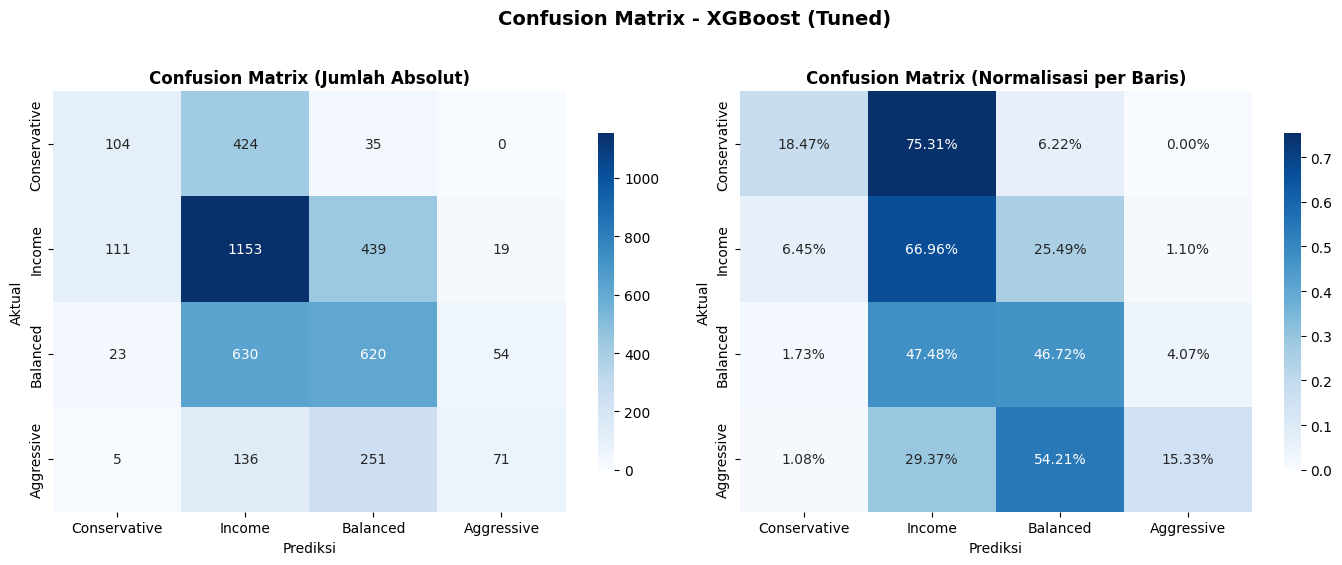

In [82]:
# ============================================================
# Confusion Matrix - XGBoost (Tuned) pada Test Set
# Urutan label diatur manual mengikuti tingkatan risiko dari paling konservatif ke paling agresif sehingga lebih mudah diinterpretasi secara visual
# ============================================================

# Mengurutkan label kategori
urutan_label = ['Conservative', 'Income', 'Balanced', 'Aggressive']

# Melakukan Confusion Matrix terhadap Test Set
cm = confusion_matrix(y_test, y_pred, labels=urutan_label)

# Buat Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Confusion matrix - jumlah absolut
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=urutan_label,
            yticklabels=urutan_label, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Confusion Matrix (Jumlah Absolut)', fontweight='bold')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# Confusion matrix - normalisasi per baris (recall view)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', xticklabels=urutan_label,
            yticklabels=urutan_label, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Confusion Matrix (Normalisasi per Baris)', fontweight='bold')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')

plt.suptitle('Confusion Matrix - XGBoost (Tuned)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

🔎 **Berikut adalah informasi yang bisa didapatkan dari Confusion Matrix dan Pola Kesalahan Klasifikasi berdasarkan hasil visualisasi diatas:**

1. **Pengamatan paling penting**: hampir seluruh kesalahan klasifikasi terjadi 
pada pasangan kelas yang **bersebelahan** dalam spektrum risiko (Conservative-Income, Income-Balanced, Balanced-Aggressive), sementara kesalahan 
antar kelas yang **berlawanan ekstrem** (Conservative-Aggressive) hampir 
tidak pernah terjadi:
* Conservative diprediksi sebagai Aggressive: **0 kasus (0.00%)**
* Aggressive diprediksi sebagai Conservative: **5 kasus dari 463 (1.08%)**

2. Dari sudut pandang bisnis yang sudah dijelaskan pada bagian Latar Belakang 
(mencegah kasus **mis-selling**), temuan ini sangat penting. Risiko mis-selling 
paling berbahaya terjadi ketika nasabah Conservative direkomendasikan 
produk berisiko tinggi (atau sebaliknya), karena berpotensi menimbulkan 
kerugian finansial yang signifikan. Model ini terbukti hampir tidak pernah 
membuat kesalahan jenis tersebut, sehingga meskipun akurasi keseluruhan 
belum tinggi, model tetap dapat diandalkan sebagai filter awal untuk 
menghindari skenario **mis-selling** yang paling merugikan.

3. Sebaliknya, kesalahan terbesar justru terjadi pada pasangan kelas yang 
berdekatan:

| Pasangan Kesalahan | Jumlah | % dari Kelas Aktual |
|---|---|---|
| Balanced -> Income | 630 | 47.48% dari total Balanced |
| Income -> Balanced | 439 | 25.49% dari total Income |
| Conservative -> Income | 424 | 75.31% dari total Conservative |
| Aggressive -> Balanced | 251 | 54.21% dari total Aggressive |
| Aggressive -> Income | 136 | 29.37% dari total Aggressive |

Temuan yang paling menonjol adalah **75.31% nasabah dengan profil 
Conservative justru diprediksi sebagai Income**. Hal ini mengindikasikan 
kedua kelas ini memiliki kemiripan perilaku transaksi yang cukup tinggi 
pada feature-feature yang tersedia (kemungkinan sama sama memiliki 
frekuensi transaksi rendah dan buy_sell_ratio yang serupa), sehingga model 
kesulitan membedakan keduanya secara tegas. Pola serupa juga terlihat pada 
54,21% nasabah Aggressive yang diprediksi sebagai Balanced, dimana 
keduanya kemungkinan sama-sama menunjukkan aktivitas transaksi yang relatif 
lebih intensif dibanding kelas lainnya.

Secara keseluruhan, model ini dapat diinterpretasikan sebagai model yang 
**"directionally correct"**, yaitu meskipun sering salah memprediksi kelas 
yang tepat, kesalahan yang terjadi jarang sekali melenceng jauh dari profil 
risiko sebenarnya.

	 Feature Importance - XGBoost (Tuned)


,Feature,Importance
0,investmentCapacity,0.130410
1,dominant_channel_Internet Banking,0.129133
2,dominant_channel_Branch,0.097925
3,dominant_asset_category_Bond,0.086972
4,customerType_Professional,0.086460
5,customerType_Mass,0.085124
6,buy_sell_ratio,0.070104
7,buy_count,0.054600
8,dominant_asset_category_MTF,0.039584
9,customer_tenure_days,0.030928


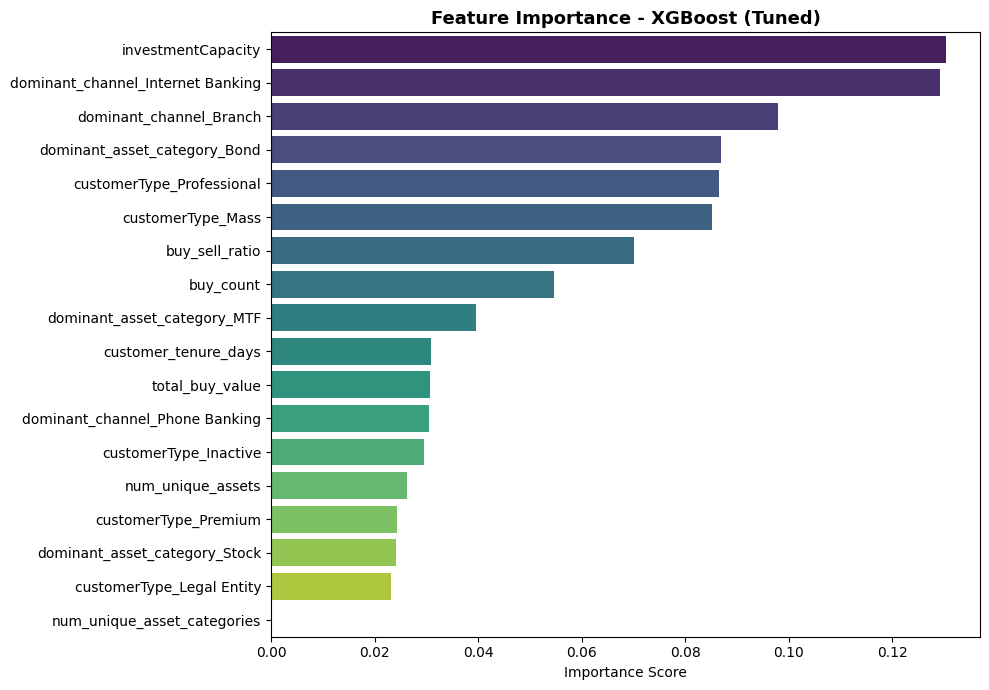

In [83]:
# ============================================================
# Feature Importance - XGBoost (Tuned)
# Mengambil nama feature hasil preprocessing agar dapat dipetakan dengan benar terhadap nilai importance dari model
# ============================================================

# Ambil nama feature dari setiap transformer di dalam preprocessor
nama_feature_numerik = kolom_numerik
nama_feature_onehot = list(
    best_xgb.named_steps['preprocessor']
    .named_transformers_['onehot']
    .get_feature_names_out(feature_onehot)
)
nama_feature_ordinal = feature_ordinal

# Menambahkan semua nama feature numerik dan kategorikal
seluruh_nama_feature = nama_feature_numerik + nama_feature_onehot + nama_feature_ordinal

# Ambil nilai importance dari model XGBoost di dalam pipeline
feature_importance = best_xgb.named_steps['model'].feature_importances_

# Buat dataframe baru
df_importance = pd.DataFrame({
    'Feature': seluruh_nama_feature,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("=" * 60)
print("\t Feature Importance - XGBoost (Tuned)")
print("=" * 60)
display(df_importance)

# Buat Visualisasi
plt.figure(figsize=(10, 7))
sns.barplot(data=df_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - XGBoost (Tuned)', fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
plt.ylabel('')
plt.tight_layout()
plt.show()

📌 **Berikut adalah insight dari hasil Feature Importance**

1. Tiga feature dengan importance tertinggi adalah **investmentCapacity**, **dominant_channel_Internet Banking**, dan 
**dominant_channel_Branch**. Temuan investmentCapacity sebagai 
feature paling berpengaruh cukup masuk akal secara konsep, mengingat 
kapasitas investasi (kemampuan finansial) merupakan salah satu pilar utama 
dalam penilaian suitability menurut regulasi MiFID II yang menjadi latar 
belakang project ini, sehingga sejalan dengan ekspektasi bisnis.

2. Ketiga feature dominant_channel (Internet Banking, Branch, dan 
Phone Banking), menjadikan kelompok feature ini sebagai kontributor terbesar secara 
agregat. Hal ini mengindikasikan kanal transaksi yang biasa digunakan 
nasabah kemungkinan menjadi proxy yang kuat terhadap profil risiko, 
mungkin terkait dengan kecenderungan demografis (misalnya nasabah pengguna 
Internet Banking cenderung lebih melek digital dan lebih aktif mengelola 
portofolionya sendiri) dibanding nasabah yang lebih banyak bertransaksi 
melalui Branch (datang ke kantor cabang).

3. **num_unique_asset_categories memiliki importance sebesar 0.00**, sama sekali tidak digunakan oleh model dalam proses splitting. Hal ini cukup kontradiktif dengan hasil ANOVA F-test pada tahap EDA sebelumnya, dimana feature ini justru menunjukkan F-statistic yang tinggi (181.26) secara univariat. Perbedaan ini dapat dijelaskan karena ANOVA F-test hanya mengukur hubungan feature tersebut secara terpisah (univariat) terhadap target, sementara feature importance 
pada model tree based seperti XGBoost bersifat multivariat, dimana feature yang informasinya sudah cukup terwakili oleh feature lain (dalam hal ini kemungkinan oleh num_unique_assets dan dummy variable dominant_asset_category) menjadi tidak lagi dibutuhkan oleh model, meski secara individual feature tersebut tetap memiliki hubungan yang signifikan terhadap target. Hal ini juga sejalan dengan temuan pada tahap EDA bahwa num_unique_asset_categories memiliki rentang nilai yang sangat sempit (hanya 1 hingga 3), sehingga informasi yang dibawanya jauh lebih general dibanding num_unique_assets yang memiliki granularitas lebih tinggi.

4. Begitupula, feature buy_sell_ratio yang pada tahap ANOVA F-test memiliki 
F-statistic tertinggi kedua (185.01), pada model akhir hanya menempati 
peringkat ketujuh dari segi importance (7.01%). Ini menjadi pengingat 
bahwa kekuatan hubungan suatu feature terhadap target secara individual 
tidak selalu berbanding lurus dengan seberapa besar kontribusi feature 
tersebut pada model akhir, karena model akhir mempertimbangkan interaksi 
antar feature secara bersamaan.

In [84]:
# ============================================================
# Analisis Detail Kesalahan Klasifikasi per Kelas
# Menghitung, untuk setiap kelas aktual, kelas apa yang paling sering salah diprediksi sebagai pengganti kelas yang benar
# ============================================================

# Buat klasifikasi kelas hasil dan salah prediksi
df_hasil = pd.DataFrame({'Aktual': y_test.values, 'Prediksi': y_pred})
df_salah = df_hasil[df_hasil['Aktual'] != df_hasil['Prediksi']]

print("=" * 60)
print("\t Pasangan Kesalahan Klasifikasi Paling Sering Terjadi")
print("=" * 60)

# Buat dataframe baru untuk pasangan yang salah
pasangan_salah = df_salah.groupby(['Aktual', 'Prediksi']).size().reset_index(name='Jumlah')
pasangan_salah = pasangan_salah.sort_values('Jumlah', ascending=False)

display(pasangan_salah.head(10))

# Cetak hasil prediksi yang salah
print(f"\nTotal data test       : {len(df_hasil)}")
print(f"Total salah prediksi   : {len(df_salah)} ({len(df_salah)/len(df_hasil)*100:.2f}%)")
# Cetak prediksi yang benar
print(f"Total benar prediksi   : {len(df_hasil) - len(df_salah)} ({(1 - len(df_salah)/len(df_hasil))*100:.2f}%)")

	 Pasangan Kesalahan Klasifikasi Paling Sering Terjadi


,Aktual,Prediksi,Jumlah
5,Balanced,Income,630
9,Income,Balanced,439
7,Conservative,Income,424
0,Aggressive,Balanced,251
2,Aggressive,Income,136
10,Income,Conservative,111
3,Balanced,Aggressive,54
6,Conservative,Balanced,35
4,Balanced,Conservative,23
8,Income,Aggressive,19



Total data test       : 4075
Total salah prediksi   : 2127 (52.20%)
Total benar prediksi   : 1948 (47.80%)


📝 Dari total 4.075 data test, model berhasil memprediksi dengan benar 
sebanyak 1.948 data (47.80%) dan salah memprediksi 2.127 data (52.20%). 
Meski terlihat tinggi, pola kesalahan yang terjadi ternyata tidak acak, 
melainkan mengikuti pola yang cukup masuk akal secara bisnis.

**Berikut Kelebihan dan Kelemahan Model:**
- **Kelebihan**: Model menunjukkan pola kesalahan yang "aman" secara bisnis, dimana kesalahan ekstrem yaitu Conservative diprediksi Aggressive tidak pernah terjadi (0 kasus dari 463 data, atau 0%) dan sebaliknya Aggresif diprediksi Conservative hanya 5 kasus dari 463 data, atau 1.08%. Hal ini krusial mengingat tujuan utama project adalah membantu mencegah kasus **mis-selling** yang paling merugikan nasabah. Selain itu, feature yang paling berpengaruh pada model (investmentCapacity) 
sejalan dengan konsep suitability assessment pada regulasi MiFID II, menunjukkan model belajar pola yang masuk akal secara domain, bukan sekadar menangkap noise pada data.

- **Kelemahan**: Recall pada kelas Aggressive dan Conservative masih sangat rendah (di bawah 19%), menunjukkan model masih kesulitan mendeteksi kedua kelas minoritas ini secara konsisten, kemungkinan besar dipengaruhi oleh ketidakseimbangan distribusi target maupun tumpang tindih pola perilaku transaksi antar kelas yang berdekatan. Selain itu, dataset yang digunakan 
hanya berisi feature perilaku transaksi dan profil dasar nasabah, tanpa adanya data toleransi risiko psikometrik yang biasanya digali langsung melalui kuesioner MiFID II resmi, sehingga terdapat batas atas (ceiling) performa yang realistis dapat dicapai oleh model ini. Hal ini sejalan dengan tujuan awal project, dimana model ini memang tidak dimaksudkan untuk 
**menggantikan kuesioner resmi**, melainkan sebagai decision support tool bagi tim Relationship Manager dan Compliance/Risk Management untuk memprioritaskan nasabah yang profil risikonya berpotensi perlu di-review ulang.

### **9. Model Saving**

Model terbaik (XGBoost setelah Hyperparameter Tuning) disimpan beserta 
label encoder dan urutan kolom feature asli dalam satu file gabungan 
(dictionary), agar proses loading pada tahap Model Inference dan Model 
Deployment menjadi lebih sederhana dan konsisten.

In [85]:
# ============================================================
# Model Saving
# Pipeline (preprocessing + model XGBoost) dan label encoder disimpan dalam satu file gabungan agar lebih mudah dan aman saat dimuat kembali pada tahap Model Inference dan Deployment
# ============================================================

# Inisialisasi model artifact
model_artifact = {
    'pipeline': best_xgb,
    'label_encoder': label_encoder,
    'feature_columns': list(X.columns)
}

with open('model_xgb_tuned.pkl', 'wb') as f:
    pickle.dump(model_artifact, f)

ukuran_model = os.path.getsize('model_xgb_tuned.pkl') / 1024
print(f"✅ Model artifact berhasil disimpan: model_xgb_tuned.pkl")
print(f"   Ukuran file : {ukuran_model:.2f} KB")

✅ Model artifact berhasil disimpan: model_xgb_tuned.pkl
   Ukuran file : 2239.46 KB


### **10. Model Inference**
Pada tahap ini pengujian dilakukan pada file yang berbeda yaitu di file (P1M2_Muhammad_Akbar_Suharbi_inf.ipynb)

#### 10.1 Kesimpulan Hasil Inference

>**Catatan:** Seluruh angka pada section ini (hasil preprocessing, hasil prediksi kelas, dan probabilitas per kelas) merupakan output dari notebook `P1M2_Muhammad_Akbar_Suharbi_inf.ipynb`.

Dari kelima data nasabah baru yang diuji, hasil prediksi menunjukkan pola 
yang sebagian besar konsisten dengan ekspektasi awal, namun juga 
mengungkap satu temuan penting yang secara langsung mengonfirmasi pola 
kesalahan yang ditemukan pada tahap Model Evaluation sebelumnya.

**✧ Prediksi yang sesuai ekspektasi:**

- **Nasabah C** (Professional, kapasitas investasi CAP_GT300K, 142 transaksi, 28 aset unik) diprediksi sebagai Aggressive dengan confidence 81.73%, tertinggi di antara seluruh nasabah yang diuji. Hasil ini sejalan dengan temuan Feature Importance sebelumnya, di mana investmentCapacity adalah feature paling berpengaruh, dan nasabah ini memang memiliki kapasitas investasi tertinggi sekaligus aktivitas transaksi paling intensif dari kelima data yang diuji.

**✧ Kasus yang mengonfirmasi pola kesalahan pada Confusion Matrix**

- **Nasabah B** (Premium, kapasitas investasi menengah, 18 transaksi, 6 aset unik, representasi profil Balanced) diprediksi sebagai Aggressive, namun dengan confidence yang sangat tipis (50.89%), hampir bersaing langsung dengan probabilitas Balanced (40.99%). Pola ini mencerminkan temuan pada Confusion Matrix, di mana 54.21% nasabah Aggressive aktual pada test set justru salah diprediksi sebagai Balanced. Di sini arahnya terbalik, tapi pasangan kelas yang tertukar tetap sama, menunjukkan model memang kesulitan memisahkan kedua kelas ini di kedua arah.

- **Nasabah A** (Mass, aktivitas transaksi sangat minim, hanya satu kali beli dan satu kali jual, tenure 1.450 hari, representasi profil Conservative) diprediksi sebagai Income dengan confidence 53.95%, dan Conservative menjadi kandidat kedua dengan probabilitas 23.74%. Ini adalah replikasi langsung dari temuan paling menonjol pada Confusion Matrix, di mana 75.31% nasabah dengan profil Conservative aktual pada test set juga salah diprediksi sebagai Income. Kemunculan pola yang sama pada data baru yang sengaja dirancang menyerupai profil Conservative memperkuat bahwa ini bukan kesalahan acak, melainkan kelemahan sistematis model dalam membedakan kedua kelas tersebut.

- **Nasabah E** (Mass, investmentCapacity hasil prediksi sistem Predicted_CAP_LT30K, aktivitas rendah, tenure 620 hari, representasi profil Income) diprediksi sebagai Income juga, tetapi dengan confidence di bawah threshold 50% (45.59%), sehingga otomatis ditandai Perlu_Review_Manual. Kandidat kedua di sini adalah Balanced (37.46%), bukan Conservative (yang hanya 4.24%), menunjukkan bahwa keraguan model pada profil nasabah dengan aktivitas rendah seperti ini condong ke arah Balanced, bukan ke Conservative seperti yang mungkin diasumsikan sekilas.

**✧ Kasus Nasabah Baru**

- **Nasabah D** (Legal Entity, tenure 0 hari karena baru bergabung, hanya satu transaksi namun bernilai besar) diprediksi sebagai Aggressive dengan confidence 70.67%, dan Balanced sebagai kandidat kedua (19.26%). Meskipun frekuensi transaksi dan tenure nasabah ini sangat minim, kapasitas investasi yang besar dan nilai transaksi tunggal yang tinggi tetap mendorong model ke arah Aggressive. Ini memberi gambaran tambahan bahwa investmentCapacity dan nilai transaksi memang lebih dominan dalam menentukan prediksi dibanding frekuensi transaksi atau lamanya menjadi nasabah.

**✧ Catatan terkait mekanisme review manual:**

* Dari kelima nasabah, hanya Nasabah E yang ditandai Perlu_Review_Manual, karena confidence-nya berada di bawah threshold 50%. Nasabah A justru tidak ditandai, meskipun confidence-nya (53.95%) hanya sedikit di atas threshold dan profil nasabah ini persis menyerupai pola yang paling sering salah diklasifikasikan (Conservative diprediksi sebagai Income). Ini menunjukkan bahwa threshold confidence tunggal sebesar 50% belum cukup sebagai satu-satunya mekanisme pengaman. Sebagai perbaikan lanjutan, mekanisme review manual sebaiknya juga mempertimbangkan business rule tambahan, misalnya menandai nasabah dengan kombinasi buy_count rendah dan customer_tenure_days tinggi untuk selalu direview secara manual, terlepas dari confidence yang dihasilkan model.

- Validasi struktur kolom menggunakan `assert` pada tahap sebelumnya juga berhasil dilalui tanpa error, membuktikan bahwa replikasi proses Handling Cardinality dan Feature Selection pada data baru sudah konsisten dengan proses yang dilakukan terhadap data training pada notebook utama, sehingga pipeline siap digunakan pada skenario produksi atau deployment.

### **11. Pengambilan Kesimpulan**

Project ini bertujuan membangun model Machine Learning Classification yang dapat memprediksi profil risiko investasi nasabah (Conservative, Income, Balanced, Aggressive) sebagai decision support tool bagi tim Relationship Manager dan Compliance/Risk Management, bukan untuk menggantikan kuesioner MiFID II resmi yang bersifat wajib secara hukum.

**🎯 Pencapaian terhadap objective:**

Dari kelima algoritma yang dibandingkan (KNN, SVM, Decision Tree, Random Forest, XGBoost) melalui baseline Cross Validation, **XGBoost setelah Hyperparameter Tuning** dipilih sebagai model terbaik dengan Accuracy 47.80% dan F1-Macro 38.08% pada test set. Meski angka ini secara absolut tergolong moderat untuk standar klasifikasi yang ideal, model terbukti memiliki karakteristik yang relevan secara bisnis dimana kesalahan klasifikasi yang terjadi hampir seluruhnya berada pada pasangan kelas yang bersebelahan dalam spektrum risiko, sementara kesalahan ekstrem (Conservative-Aggressive) yang paling berbahaya dari sisi mis-selling tidak pernah terjadi (0 kasus dari 463 data, atau 0%). Temuan ini terkonfirmasi ulang secara independen pada notebook Model Inference, di mana data nasabah baru yang dirancang menyerupai profil Conservative (Nasabah A) justru diprediksi sebagai Income dengan Conservative sebagai kandidat kedua, replikasi langsung dari pola sistematis yang sama.

**✯ Kelebihan model:**
- Feature paling berpengaruh (investmentCapacity) sejalan dengan konsep suitability assessment pada regulasi MiFID II, menunjukkan model menangkap pola yang masuk akal secara domain bisnis, bukan sekadar noise.
- Pola kesalahan yang "aman" (directionally correct) membuat model layak dipakai sebagai filter awal untuk memprioritaskan nasabah yang perlu ditinjau ulang, sesuai dengan posisi model sebagai decision support tool, bukan pengambil keputusan otomatis.

**✯ Keterbatasan model:**
- Recall pada kelas minoritas Aggressive dan Conservative masih rendah (di bawah 19%), sehingga banyak nasabah dengan profil risiko ekstrem yang justru terlewat dan masuk ke kelas tengah.
- Dataset hanya berisi data profil dan perilaku transaksi, tanpa data toleransi risiko psikometrik yang biasanya digali langsung melalui kuesioner resmi, sehingga terdapat batas atas performa yang realistis dapat dicapai model berbasis data perilaku semata.
- Mekanisme review manual berbasis threshold confidence tunggal (50%) terbukti belum cukup menangkap seluruh kasus berisiko tinggi salah klasifikasi, sebagaimana ditemukan pada notebook Model Inference.
- Masih banyak feature improvement yang bisa dilakukan untuk membuat model ini lebih baik namun karena keterbatasan waktu pengumpulan project yang singkat membuat ruang untuk explore lebih dalam terbatas.

**🧑🏼‍💻 Rekomendasi penggunaan:**

Model ini direkomendasikan untuk digunakan sebagai alat bantu prioritisasi 
awal, bukan sebagai pengganti keputusan akhir compliance. Idealnya, hasil 
prediksi model dikombinasikan dengan business rule tambahan (misalnya 
kombinasi aktivitas transaksi sangat rendah dan tenure panjang) sebagai 
lapisan kedua sebelum keputusan akhir diambil oleh tim Relationship Manager dan Compliance/Risk Management, terutama untuk nasabah yang belum pernah mengisi kuesioner risiko resmi sama sekali.